# In Silico `Toxicity` prediction for `Bacillus Anthracis` Antibiotic Candidates

This workflow uses `admet_ai` predictions to perform a **rule-based safety triage** of candidate molecules.

The goal is to support **early prioritization**, not to make definitive toxicity claims.

We separate predictions into three categories:

- **Core toxicity risk**: direct safety concerns such as hERG, DILI, AMES, and ClinTox
- **Mechanistic alerts**: stress-response and nuclear-receptor pathway signals
- **ADME / metabolism liabilities**: permeability, transporter, and CYP-related liabilities that may affect developability but do not necessarily imply intrinsic toxicity

In [3]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [4]:
import numpy as np
import pandas as pd
import pubchempy as pcp
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from admet_ai import ADMETModel
import matplotlib.pyplot as plt

In [18]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')
saveDir = os.path.join(resultsDir, "Bacillus_anthracis_bestMACAW/")
DORANETmoleculesDataDir = os.path.join(dataDir, 'DORAnet_molecules/')
ARTresultsDir = os.path.join(dataDir, 'Results/Bacillus_anthracis_bestMACAW/')
os.makedirs(saveDir, exist_ok=True)

## Check toxicty for `buyable` AntiviralsData set

In [21]:
BacillusAnthracisVirus_wART_Buyable_predicted_all = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction.csv')
max_val = BacillusAnthracisVirus_wART_Buyable_predicted_all['pPotency_prediction'].max()
min_val = BacillusAnthracisVirus_wART_Buyable_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracisVirus_wART_Buyable_predicted_all

pPotency_prediction range: 0.883 → 6.329


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,2.420812,1.929846,-1.361687,6.203311,0.003795,6.261649e-07,22.997815
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,3.495472,1.932781,-0.292779,7.283722,0.000320,5.203287e-08,1.962362
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,2.896828,1.930401,-0.886757,6.680413,0.001268,2.087308e-07,7.704731
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,3.727565,1.934292,-0.063648,7.518778,0.000187,3.028464e-08,1.157837
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.094989,1.938103,0.296307,7.893671,0.000080,1.277407e-08,0.505467
...,...,...,...,...,...,...,...,...
59746,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.226625,1.954812,0.395194,8.058056,0.000059,8.748705e-09,0.402537
59747,CNc1nc(Nc2ccccc2F)nc2ccccc12,3.635805,1.958712,-0.203271,7.474882,0.000231,3.350567e-08,1.596876
59748,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.236636,1.962426,0.390281,8.082991,0.000058,8.260558e-09,0.407117
59749,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,3.757461,1.971891,-0.107446,7.622368,0.000175,2.385790e-08,1.280697


### Read predicted ADMET properties for all candidate SMILES

In [22]:
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_wToxicity.csv')
max_val = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity

pPotency_prediction range: 1.082 → 6.329


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,2.420812,1.929846,-1.361687,6.203311,0.003795,6.261649e-07,22.997815,374.397,3.12552,...,49.127569,94.998061,92.943001,37.999225,83.094223,16.905777,80.806514,82.551377,21.170997,93.524622
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,3.495472,1.932781,-0.292779,7.283722,0.000320,5.203287e-08,1.962362,338.393,1.33666,...,36.603335,55.796820,70.104692,0.736720,22.799535,13.067080,41.682823,70.414889,45.599069,21.868941
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,2.896828,1.930401,-0.886757,6.680413,0.001268,2.087308e-07,7.704731,384.454,0.45232,...,52.113222,91.624661,85.653354,0.969368,41.837922,19.658782,31.562621,44.939899,58.821249,55.409073
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,3.727565,1.934292,-0.063648,7.518778,0.000187,3.028464e-08,1.157837,346.416,1.90460,...,33.772780,59.053897,33.074835,59.790617,27.917798,28.266770,28.925940,44.784800,57.813106,14.850717
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.094989,1.938103,0.296307,7.893671,0.000080,1.277407e-08,0.505467,341.772,2.47350,...,21.907716,22.373013,11.205894,40.907328,36.874758,65.645599,15.471113,94.571539,59.092672,11.322218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46941,CNc1nc(Nc2ccccc2)nc2ccccc12,3.865233,1.959841,0.023946,7.706521,0.000136,1.965527e-08,0.946355,250.305,3.41510,...,75.300504,88.522683,94.920512,91.547111,48.933695,28.809616,87.436991,85.188057,23.497480,89.647150
46942,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.226625,1.954812,0.395194,8.058056,0.000059,8.748705e-09,0.402537,254.268,3.09470,...,63.474215,74.951532,86.816596,73.904614,31.252423,70.608763,78.092284,72.974021,40.209383,45.599069
46943,CNc1nc(Nc2ccccc2F)nc2ccccc12,3.635805,1.958712,-0.203271,7.474882,0.000231,3.350567e-08,1.596876,268.295,3.55420,...,73.943389,86.390074,95.851105,88.716557,45.250097,55.215200,88.483908,83.288096,26.056611,57.464133
46944,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.236636,1.962426,0.390281,8.082991,0.000058,8.260558e-09,0.407117,270.723,3.60900,...,70.182241,84.877860,91.469562,88.290035,32.997286,70.531214,83.637069,79.643273,26.715781,93.175649


### Retain potency predictions along with toxicity, mechanistic, and ADME-related endpoints

In [23]:
# Potency-related columns
potencyCols = [
    "SMILES",
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.columns
]

BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.shape)
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.head()

Filtered dataframe shape: (46946, 41)


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,2.420812,1.929846,-1.361687,6.203311,0.003795,6.261649e-07,22.997815,0.727207,0.499834,...,0.995333,0.889405,0.556546,0.952716,0.115046,0.826106,0.134753,0.108329,0.760515,0.592387
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,3.495472,1.932781,-0.292779,7.283722,0.000320,5.203287e-08,1.962362,0.204361,0.089317,...,0.949429,0.973717,0.730353,0.310337,0.474573,0.095773,0.269003,0.008871,0.549327,0.044814
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,2.896828,1.930401,-0.886757,6.680413,0.001268,2.087308e-07,7.704731,0.312347,0.181800,...,0.925759,0.893960,0.012659,0.420566,0.319929,0.083655,0.081229,0.007386,0.524254,0.148049
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,3.727565,1.934292,-0.063648,7.518778,0.000187,3.028464e-08,1.157837,0.049025,0.109170,...,0.842507,0.874405,0.007123,0.112539,0.517903,0.071035,0.050239,0.037251,0.335556,0.179092
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.094989,1.938103,0.296307,7.893671,0.000080,1.277407e-08,0.505467,0.008243,0.031413,...,0.110157,0.798915,0.050893,0.081878,0.708961,0.196669,0.026894,0.021543,0.313643,0.009893


### Read ADMET endpoints of the FDA approved Drug data from `Drugbank`

In [24]:
drugBankDrugData_approved_ADMET_summary = pd.read_csv(dataDir + 'Toxicity/DrugBank/drugBankDrugData_ADMET_summary.csv')
drugBankDrugData_approved_ADMET_summary

,Endpoint,Min,Max,Range,Mean,Std
0,AMES,4.580234e-05,0.999994,0.999949,0.299619,0.249049
1,hERG,5.135011e-05,0.997788,0.997737,0.434110,0.340795
2,DILI,1.172916e-05,0.998585,0.998573,0.565484,0.337805
3,ClinTox,6.131192e-09,0.955574,0.955574,0.217150,0.212429
4,Carcinogens_Lagunin,3.302558e-04,0.991252,0.990921,0.230227,0.199003
5,Skin_Reaction,6.183962e-03,0.999993,0.993809,0.433260,0.253876
6,LD50_Zhu,-4.707379e-02,6.023548,6.070622,2.546885,0.656044
7,SR-ARE,2.767653e-05,0.999029,0.999002,0.272911,0.251478
8,SR-ATAD5,3.475998e-13,0.986187,0.986187,0.058122,0.110646
9,SR-HSE,1.241251e-11,0.965706,0.965706,0.068353,0.120833


### Filter compounds based on the results from Drugbank's `ADMET` summary

In [25]:
# ── Build range lookup dict from summary dataframe ─────────────────────────────
# Ensure Endpoint is the index and numeric types are correct
summaryDF = drugBankDrugData_approved_ADMET_summary.copy()

if "Endpoint" in summaryDF.columns:
    summaryDF = summaryDF.set_index("Endpoint")

summaryDF = summaryDF.astype(float)

rangeDict = summaryDF[["Min", "Max"]].to_dict(orient="index")

# ── Range mask builder ─────────────────────────────────────────────────────────
def buildRangeMask(df, endpointCols, rangeDict):
    """
    Returns a boolean Series: True if ALL available endpoints in endpointCols
    fall within [Min, Max] defined in rangeDict.
    Skips endpoints missing from either the dataframe or the rangeDict.
    """
    mask = pd.Series(True, index=df.index)
    skipped = []
    applied = []

    for col in endpointCols:
        if col not in df.columns or col not in rangeDict:
            skipped.append(col)
            continue
        colMin = rangeDict[col]["Min"]
        colMax = rangeDict[col]["Max"]
        mask = mask & df[col].between(colMin, colMax, inclusive="both")
        applied.append(col)

    return mask, applied, skipped


df = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.copy()
total = len(df)

# ── Apply masks per category ───────────────────────────────────────────────────
coreMask,        coreApplied,        coreSkipped        = buildRangeMask(df, coreToxicityCols,     rangeDict)
mechanisticMask, mechanisticApplied, mechanisticSkipped = buildRangeMask(df, mechanisticAlertCols, rangeDict)
admeMask,        admeApplied,        admeSkipped        = buildRangeMask(df, admeLiabilityCols,    rangeDict)

# Combined: must pass all three categories simultaneously
combinedMask = coreMask & mechanisticMask & admeMask

# ── Filter dataframes ──────────────────────────────────────────────────────────
df_coreFiltered        = df[coreMask].reset_index(drop=True)
df_mechanisticFiltered = df[mechanisticMask].reset_index(drop=True)
df_admeFiltered        = df[admeMask].reset_index(drop=True)
df_allFiltered         = df[combinedMask].reset_index(drop=True)

# ── Report 
print("         DrugBank Approved Range Filtering Summary")
print(f"Total input molecules: {total}")

print(f"\n──> Core Toxicity Endpoints ")
print(f"  Endpoints applied : {coreApplied}")
print(f"  Endpoints skipped : {coreSkipped}")
print(f"  Passing molecules : {len(df_coreFiltered)} / {total}  ({len(df_coreFiltered)/total*100:.2f}%)")

print(f"\n──> Mechanistic Alert Endpoints ")
print(f"  Endpoints applied : {mechanisticApplied}")
print(f"  Endpoints skipped : {mechanisticSkipped}")
print(f"  Passing molecules : {len(df_mechanisticFiltered)} / {total}  ({len(df_mechanisticFiltered)/total*100:.2f}%)")

print(f"\n──> ADME / Metabolism Liability Endpoints ")
print(f"  Endpoints applied : {admeApplied}")
print(f"  Endpoints skipped : {admeSkipped}")
print(f"  Passing molecules : {len(df_admeFiltered)} / {total}  ({len(df_admeFiltered)/total*100:.2f}%)")

print(f"\n──> Combined (ALL categories must pass) ")
print(f"  Passing molecules : {len(df_allFiltered)} / {total}  ({len(df_allFiltered)/total*100:.2f}%)")
print("=" * 65)

# ── Inspect results ────────────────────────────────────────────────────────────
print("\nCombined filtered dataframe shape:", df_allFiltered.shape)
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity = df_allFiltered.copy()
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity

         DrugBank Approved Range Filtering Summary
Total input molecules: 46946

──> Core Toxicity Endpoints 
  Endpoints applied : ['AMES', 'hERG', 'DILI', 'ClinTox', 'Carcinogens_Lagunin', 'Skin_Reaction', 'LD50_Zhu']
  Endpoints skipped : []
  Passing molecules : 46943 / 46946  (99.99%)

──> Mechanistic Alert Endpoints 
  Endpoints applied : ['SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'NR-AR-LBD', 'NR-AR', 'NR-AhR', 'NR-Aromatase', 'NR-ER-LBD', 'NR-ER', 'NR-PPAR-gamma']
  Endpoints skipped : []
  Passing molecules : 46918 / 46946  (99.94%)

──> ADME / Metabolism Liability Endpoints 
  Endpoints applied : ['BBB_Martins', 'Pgp_Broccatelli', 'Caco2_Wang', 'HIA_Hou', 'PAMPA_NCATS', 'Bioavailability_Ma', 'CYP1A2_Veith', 'CYP2C19_Veith', 'CYP2C9_Substrate_CarbonMangels', 'CYP2C9_Veith', 'CYP2D6_Substrate_CarbonMangels', 'CYP2D6_Veith', 'CYP3A4_Substrate_CarbonMangels', 'CYP3A4_Veith']
  Endpoints skipped : []
  Passing molecules : 46930 / 46946  (99.97%)

──> Combined (ALL catego

,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,2.420812,1.929846,-1.361687,6.203311,0.003795,6.261649e-07,22.997815,0.727207,0.499834,...,0.995333,0.889405,0.556546,0.952716,0.115046,0.826106,0.134753,0.108329,0.760515,0.592387
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,3.495472,1.932781,-0.292779,7.283722,0.000320,5.203287e-08,1.962362,0.204361,0.089317,...,0.949429,0.973717,0.730353,0.310337,0.474573,0.095773,0.269003,0.008871,0.549327,0.044814
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,2.896828,1.930401,-0.886757,6.680413,0.001268,2.087308e-07,7.704731,0.312347,0.181800,...,0.925759,0.893960,0.012659,0.420566,0.319929,0.083655,0.081229,0.007386,0.524254,0.148049
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,3.727565,1.934292,-0.063648,7.518778,0.000187,3.028464e-08,1.157837,0.049025,0.109170,...,0.842507,0.874405,0.007123,0.112539,0.517903,0.071035,0.050239,0.037251,0.335556,0.179092
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.094989,1.938103,0.296307,7.893671,0.000080,1.277407e-08,0.505467,0.008243,0.031413,...,0.110157,0.798915,0.050893,0.081878,0.708961,0.196669,0.026894,0.021543,0.313643,0.009893
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46895,CCNC(=O)c1nc2cc(C)c(C)cc2n(CC)c1=O,3.297085,1.935425,-0.496348,7.090518,0.000505,8.118614e-08,3.135798,0.379785,0.291666,...,0.991187,0.960157,0.972321,0.260312,0.379898,0.099946,0.374757,0.012436,0.691256,0.096526
46896,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.226625,1.954812,0.395194,8.058056,0.000059,8.748705e-09,0.402537,0.873983,0.718039,...,0.966828,0.975339,0.989924,0.544212,0.197318,0.101835,0.190628,0.294455,0.583118,0.766461
46897,CNc1nc(Nc2ccccc2F)nc2ccccc12,3.635805,1.958712,-0.203271,7.474882,0.000231,3.350567e-08,1.596876,0.844169,0.862255,...,0.985745,0.975515,0.998813,0.609740,0.275892,0.075060,0.447296,0.643535,0.618640,0.917848
46898,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.236636,1.962426,0.390281,8.082991,0.000058,8.260558e-09,0.407117,0.767482,0.514581,...,0.971024,0.960092,0.991350,0.585246,0.125267,0.098983,0.148127,0.330043,0.625401,0.565977


### Multiparameter optimization (MPO) framework based ADMET scoring

We replaced simple arithmetic averaging with a weighted desirability-based multiparameter optimization (MPO) framework. Each ADMET endpoint was converted to a 0–1 desirability value, where `1 --> favorable` and `0 --> unfavorable` profile. Category-level scores were then combined using weighted geometric means, following the same general pattern used in QED and ADMET-score approaches.

**References**

1. ADMET-score – a comprehensive scoring function for evaluation of chemical drug-likeness (https://pubs.rsc.org/en/content/articlelanding/2019/md/c8md00472b)
2. Quantifying the chemical beauty of drugs (https://www.nature.com/articles/nchem.1243)

In [26]:
df = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity.copy()


# Endpoint groups
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu",
]

mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma",
]

# Define these lists according to how you want to treat directionality
# lower-is-better => toxicity/liability style probabilities
admeLowerIsBetter = [
    "Pgp_Broccatelli",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith",
]

# higher-is-better => absorption / permeability / bioavailability style endpoints
admeHigherIsBetter = [
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
]

# Optional / context-dependent endpoint
# For non-CNS antivirals, you may wish to penalize BBB penetration.
# For CNS programs, you may want the opposite or exclude it from the score.
includeBBB = False
if includeBBB and "BBB_Martins" in df.columns:
    admeLowerIsBetter = admeLowerIsBetter + ["BBB_Martins"]


# Utilities
epsilon = 1e-6

def clip01(series):
    return series.clip(lower=epsilon, upper=1 - epsilon)

def desirabilityFromRiskProbability(series):
    """
    For toxicity/liability probabilities:
    lower risk is better -> desirability = 1 - p
    """
    return clip01(1 - series)

def desirabilityFromBenefitProbability(series):
    """
    For favorable probabilities/scores already in [0,1]:
    higher is better -> desirability = p
    """
    return clip01(series)

def desirabilityFromLD50(series, lowerQuantile=0.10, upperQuantile=0.90):
    """
    LD50_Zhu is treated as a regression-style acute toxicity endpoint.
    Higher LD50_Zhu implies greater acute toxicity risk.
    Map lower values -> high desirability, higher values -> low desirability.

    Uses a robust percentile-based linear desirability transform so the score
    is less sensitive to extreme outliers than plain min-max scaling.
    """
    qLow = series.quantile(lowerQuantile)
    qHigh = series.quantile(upperQuantile)

    if pd.isna(qLow) or pd.isna(qHigh) or qHigh == qLow:
        return pd.Series(0.5, index=series.index)

    # lower LD50_Zhu = better, higher = worse
    desirability = 1 - ((series - qLow) / (qHigh - qLow))
    return clip01(desirability)

def weightedGeometricMean(dfValues, weightsDict):
    """
    Compute weighted geometric mean across available columns only.
    """
    availableCols = [col for col in weightsDict if col in dfValues.columns]
    if len(availableCols) == 0:
        return pd.Series(np.nan, index=dfValues.index)

    weights = np.array([weightsDict[col] for col in availableCols], dtype=float)
    weights = weights / weights.sum()

    values = dfValues[availableCols].copy()
    values = values.clip(lower=epsilon, upper=1 - epsilon)

    logWeighted = np.log(values).mul(weights, axis=1).sum(axis=1)
    return np.exp(logWeighted)

# -----------------------------------------------------------------------------
# 1. Core toxicity desirability
# -----------------------------------------------------------------------------
coreWeights = {
    "AMES": 1.0,
    "hERG": 1.5,
    "DILI": 1.5,
    "ClinTox": 1.5,
    "Carcinogens_Lagunin": 1.0,
    "Skin_Reaction": 0.5,
    "LD50_Zhu": 1.25,
}

coreDesirabilityDF = pd.DataFrame(index=df.index)

for colName in coreToxicityCols:
    if colName not in df.columns:
        continue

    if colName == "LD50_Zhu":
        coreDesirabilityDF[colName] = desirabilityFromLD50(df[colName])
    else:
        coreDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

df["Core_Toxicity_Desirability"] = weightedGeometricMean(coreDesirabilityDF, coreWeights)

# Optional inverse form if you want "higher = worse"
df["Core_Toxicity_Score"] = 1 - df["Core_Toxicity_Desirability"]

# -----------------------------------------------------------------------------
# 2. Mechanistic alert desirability
# -----------------------------------------------------------------------------
mechWeights = {
    "SR-ARE": 1.0,
    "SR-ATAD5": 1.0,
    "SR-HSE": 0.75,
    "SR-MMP": 1.25,
    "SR-p53": 1.0,
    "NR-AR-LBD": 0.75,
    "NR-AR": 0.75,
    "NR-AhR": 0.75,
    "NR-Aromatase": 0.75,
    "NR-ER-LBD": 0.75,
    "NR-ER": 0.75,
    "NR-PPAR-gamma": 0.5,
}

mechDesirabilityDF = pd.DataFrame(index=df.index)
for colName in mechanisticAlertCols:
    if colName in df.columns:
        mechDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

df["Mechanistic_Alert_Desirability"] = weightedGeometricMean(mechDesirabilityDF, mechWeights)
df["Mechanistic_Alert_Score"] = 1 - df["Mechanistic_Alert_Desirability"]

# -----------------------------------------------------------------------------
# 3. ADME liability desirability
# -----------------------------------------------------------------------------
admeWeights = {
    "BBB_Martins": 0.5,   # context dependent
    "Pgp_Broccatelli": 1.0,
    "Caco2_Wang": 1.0,
    "HIA_Hou": 1.0,
    "PAMPA_NCATS": 0.75,
    "Bioavailability_Ma": 1.25,
    "CYP1A2_Veith": 1.0,
    "CYP2C19_Veith": 1.0,
    "CYP2C9_Substrate_CarbonMangels": 0.75,
    "CYP2C9_Veith": 1.0,
    "CYP2D6_Substrate_CarbonMangels": 0.75,
    "CYP2D6_Veith": 1.0,
    "CYP3A4_Substrate_CarbonMangels": 0.75,
    "CYP3A4_Veith": 1.0,
}

admeDesirabilityDF = pd.DataFrame(index=df.index)

for colName in admeLowerIsBetter:
    if colName in df.columns:
        admeDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

for colName in admeHigherIsBetter:
    if colName in df.columns:
        admeDesirabilityDF[colName] = desirabilityFromBenefitProbability(df[colName])

df["ADME_Desirability"] = weightedGeometricMean(admeDesirabilityDF, admeWeights)
df["ADME_Liability_Score"] = 1 - df["ADME_Desirability"]

# -----------------------------------------------------------------------------
# 4. Final MPO-style safety score
# -----------------------------------------------------------------------------
# Higher desirability = better
# We give core toxicity the highest influence, then ADME, then mechanistic alerts.
componentDesirabilityDF = pd.DataFrame({
    "Core_Toxicity_Desirability": df["Core_Toxicity_Desirability"],
    "Mechanistic_Alert_Desirability": df["Mechanistic_Alert_Desirability"],
    "ADME_Desirability": df["ADME_Desirability"],
})

componentWeights = {
    "Core_Toxicity_Desirability": 0.50,
    "Mechanistic_Alert_Desirability": 0.20,
    "ADME_Desirability": 0.30,
}

df["Safety_MPO_Desirability"] = weightedGeometricMean(
    componentDesirabilityDF,
    componentWeights
)

# Optional inverse form if you want higher = worse
df["Safety_MPO_RiskScore"] = 1 - df["Safety_MPO_Desirability"]

# -----------------------------------------------------------------------------
# 5. Markdown-style explanation column
# -----------------------------------------------------------------------------
markdownNote = (
    "Composite scores were computed using a weighted desirability-based MPO framework. "
    "Each endpoint was transformed to a 0–1 desirability value, then combined with a "
    "weighted geometric mean. Core toxicity used AMES, hERG, DILI, ClinTox, "
    "Carcinogens_Lagunin, Skin_Reaction, and LD50_Zhu; mechanistic score used SR/NR "
    "alerts; ADME score used direction-adjusted absorption, transporter, and CYP endpoints. "
    "This follows the general scoring pattern used in QED and ADMET-score literature."
)

df["Scoring_Method_Markdown"] = markdownNote

# -----------------------------------------------------------------------------
# 6. Final output
# -----------------------------------------------------------------------------
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_sorted = df[
    [
        "SMILES",
        "pPotency_prediction",
        "pPotency_std",
        "Core_Toxicity_Desirability",
        "Core_Toxicity_Score",
        "Mechanistic_Alert_Desirability",
        "Mechanistic_Alert_Score",
        "ADME_Desirability",
        "ADME_Liability_Score",
        "Safety_MPO_Desirability",
        "Safety_MPO_RiskScore",
        "Scoring_Method_Markdown",
    ]
].copy()

BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_sorted

,SMILES,pPotency_prediction,pPotency_std,Core_Toxicity_Desirability,Core_Toxicity_Score,Mechanistic_Alert_Desirability,Mechanistic_Alert_Score,ADME_Desirability,ADME_Liability_Score,Safety_MPO_Desirability,Safety_MPO_RiskScore,Scoring_Method_Markdown
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,2.420812,1.929846,0.418714,0.581286,0.826614,0.173386,0.148864,0.851136,0.351768,0.648232,Composite scores were computed using a weighte...
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,3.495472,1.932781,0.513034,0.486966,0.958606,0.041394,0.247744,0.752256,0.467307,0.532693,Composite scores were computed using a weighte...
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,2.896828,1.930401,0.551077,0.448923,0.967890,0.032110,0.274274,0.725726,0.500295,0.499705,Composite scores were computed using a weighte...
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,3.727565,1.934292,0.579369,0.420631,0.987124,0.012876,0.281582,0.718418,0.519079,0.480921,Composite scores were computed using a weighte...
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.094989,1.938103,0.454178,0.545822,0.978505,0.021495,0.240716,0.759284,0.437700,0.562300,Composite scores were computed using a weighte...
...,...,...,...,...,...,...,...,...,...,...,...,...
46895,CCNC(=O)c1nc2cc(C)c(C)cc2n(CC)c1=O,3.297085,1.935425,0.481635,0.518365,0.913697,0.086303,0.201160,0.798840,0.421291,0.578709,Composite scores were computed using a weighte...
46896,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.226625,1.954812,0.210977,0.789023,0.387507,0.612493,0.162965,0.837035,0.220497,0.779503,Composite scores were computed using a weighte...
46897,CNc1nc(Nc2ccccc2F)nc2ccccc12,3.635805,1.958712,0.212360,0.787640,0.370128,0.629872,0.112724,0.887276,0.196251,0.803749,Composite scores were computed using a weighte...
46898,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.236636,1.962426,0.244890,0.755110,0.361240,0.638760,0.167534,0.832466,0.236198,0.763802,Composite scores were computed using a weighte...


### Define filter for compound ranking based on `ADMET` scores

In [30]:
pPotency_prediction_cutoff = 4
Core_Toxicity_cutoff = 0.3
Mechanistic_Alert_cutoff = 0.3
ADME_Liability_cutoff = 0.3

In [31]:
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_core = (
    BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_sorted[
        (BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_sorted["pPotency_prediction"] > pPotency_prediction_cutoff) &
        (BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_sorted["Core_Toxicity_Score"] < Core_Toxicity_cutoff)
    ]
    .reset_index(drop=True)
)


BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_core.to_csv(resultsDir + 
                                                                           'BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_nonToxic_core.csv', index=False, encoding="utf-8")
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_core

,SMILES,pPotency_prediction,pPotency_std,Core_Toxicity_Desirability,Core_Toxicity_Score,Mechanistic_Alert_Desirability,Mechanistic_Alert_Score,ADME_Desirability,ADME_Liability_Score,Safety_MPO_Desirability,Safety_MPO_RiskScore,Scoring_Method_Markdown
0,NCc1ccc(C(=O)NCc2ccccn2)cc1,4.844479,1.931815,0.702494,0.297506,0.960839,0.039161,0.292893,0.707107,0.575260,0.424740,Composite scores were computed using a weighte...
1,COc1cccc(C(O)C(=O)Nc2ccc(CN)cc2)c1,4.175000,1.941063,0.725640,0.274360,0.939513,0.060487,0.259034,0.740966,0.560981,0.439019,Composite scores were computed using a weighte...
2,NCc1cc(CC(=O)Nc2cccc(O)c2F)ccn1,4.120685,1.936738,0.702908,0.297092,0.938467,0.061533,0.256318,0.743682,0.550258,0.449742,Composite scores were computed using a weighte...
3,Cc1csc(COc2ccccc2CN)n1,4.423438,1.936913,0.735884,0.264116,0.894398,0.105602,0.158127,0.841873,0.482406,0.517594,Composite scores were computed using a weighte...
4,COc1cccc(CC(=O)NCc2ccc(CS(N)(=O)=O)cc2)c1,4.526990,1.936377,0.731041,0.268959,0.973389,0.026611,0.257967,0.742033,0.566366,0.433634,Composite scores were computed using a weighte...
5,Cc1cccc(CN(Cc2ccccn2)C(=O)CN)c1,4.084647,1.936954,0.701148,0.298852,0.976525,0.023475,0.214053,0.785947,0.524805,0.475195,Composite scores were computed using a weighte...
6,NCc1ccc(CC(=O)NC2(C(N)=O)CCOc3ccccc32)cc1,4.452832,1.954952,0.736058,0.263942,0.964630,0.035370,0.264613,0.735387,0.571625,0.428375,Composite scores were computed using a weighte...
7,COC(=O)N(C)CC(=O)NCc1cccc(Cn2ccnc2)c1,4.014159,1.940190,0.736337,0.263663,0.977639,0.022361,0.210728,0.789272,0.535416,0.464584,Composite scores were computed using a weighte...
8,COCCS(=O)(=O)NC1CCN(Cc2ccccn2)CC1,4.185739,1.940736,0.783802,0.216198,0.991131,0.008869,0.290522,0.709478,0.609934,0.390066,Composite scores were computed using a weighte...
9,N#CCCS(=O)(=O)NC(=O)CCOCc1ccccc1,4.042638,1.950562,0.741109,0.258891,0.975521,0.024479,0.282325,0.717675,0.586156,0.413844,Composite scores were computed using a weighte...


### Plot full distribution + highlighted filtered dataframe

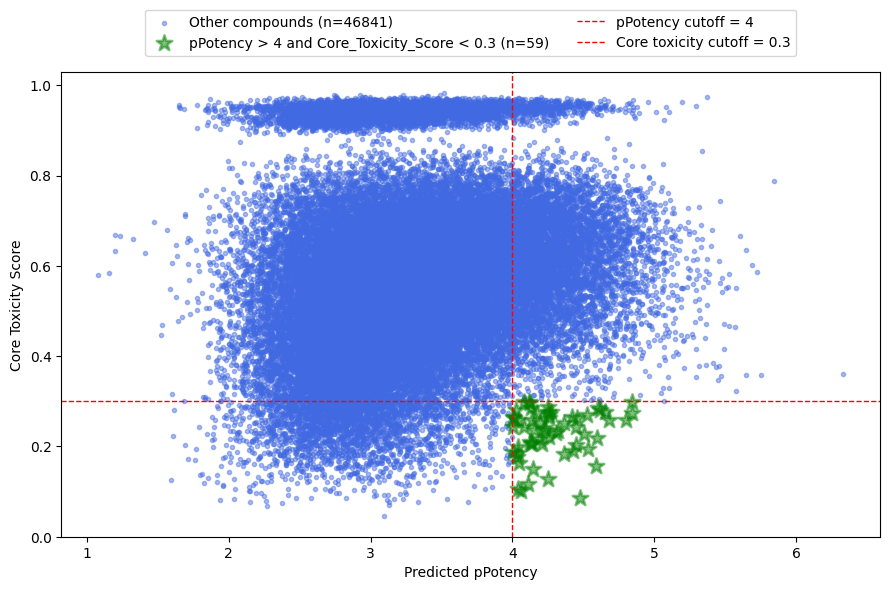

In [32]:
plotDF = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_sorted.copy()
highlightDF = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_core.copy()

# Rebuild mask from predefined cutoffs
highlightMask = (
    (plotDF["pPotency_prediction"] > pPotency_prediction_cutoff) &
    (plotDF["Core_Toxicity_Score"] < Core_Toxicity_cutoff)
)

backgroundDF = plotDF[~highlightMask]

otherCount = len(backgroundDF)
highlightCount = len(highlightDF)

plt.figure(figsize=(9, 6))

# Plot all other compounds
plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Other compounds (n={otherCount})"
)

# Plot filtered core compounds
plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Core_Toxicity_Score"],
    alpha=0.5,
    marker="*",
    s=140,
    c="g",
    linewidths=1.8,
    label=f"pPotency > {pPotency_prediction_cutoff} and Core_Toxicity_Score < {Core_Toxicity_cutoff} (n={highlightCount})"
)

plt.axvline(
    x=pPotency_prediction_cutoff,
    c="r",
    linestyle="--",
    linewidth=1,
    label=f"pPotency cutoff = {pPotency_prediction_cutoff}"
)

plt.axhline(
    y=Core_Toxicity_cutoff,
    c="r",
    linestyle="--",
    linewidth=1,
    label=f"Core toxicity cutoff = {Core_Toxicity_cutoff}"
)

plt.xlabel("Predicted pPotency")
plt.ylabel("Core Toxicity Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.tight_layout()
plt.show()

### Create filtered dataframe with `Mechanistic_Alert_Score` & `ADME_Liability_Score`

In [33]:
# Select best overall compounds
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_allEndpoints = (
    BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_sorted[
        (BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_sorted["pPotency_prediction"] >= pPotency_prediction_cutoff) &
        (BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_sorted["Core_Toxicity_Score"] < Core_Toxicity_cutoff) &
        (BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_sorted["Mechanistic_Alert_Score"] < Mechanistic_Alert_cutoff) &
        (BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_sorted["ADME_Liability_Score"] < ADME_Liability_cutoff)
    ]
    .copy()
)


BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_allEndpoints.to_csv(resultsDir + 
                                                                           'BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_allEndpoints.csv', index=False, encoding="utf-8")
BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_allEndpoints

,SMILES,pPotency_prediction,pPotency_std,Core_Toxicity_Desirability,Core_Toxicity_Score,Mechanistic_Alert_Desirability,Mechanistic_Alert_Score,ADME_Desirability,ADME_Liability_Score,Safety_MPO_Desirability,Safety_MPO_RiskScore,Scoring_Method_Markdown


Total compounds: 46900
Best overall compounds: 0


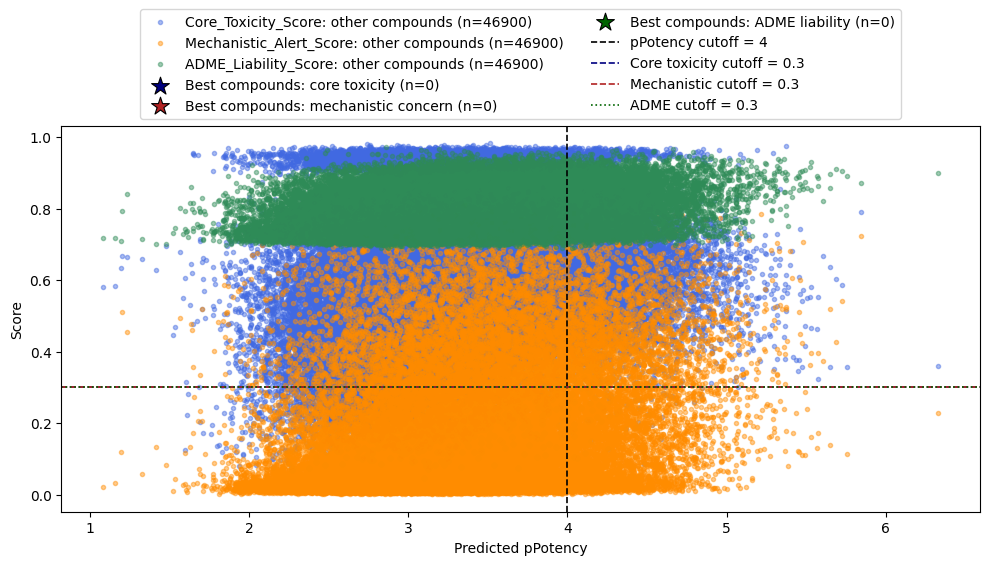

In [34]:
plotDF = BacillusAnthracisVirus_wART_BuyableDataset_predicted_all_wToxicity_sorted.copy()

highlightMask = (
    (plotDF["pPotency_prediction"] >= pPotency_prediction_cutoff) &
    (plotDF["Core_Toxicity_Score"] < Core_Toxicity_cutoff) &
    (plotDF["Mechanistic_Alert_Score"] < Mechanistic_Alert_cutoff) &
    (plotDF["ADME_Liability_Score"] < ADME_Liability_cutoff)
)

backgroundDF = plotDF[~highlightMask]
highlightDF = plotDF[highlightMask].copy()

otherCount = len(backgroundDF)
highlightCount = len(highlightDF)
totalCount = len(plotDF)

print("Total compounds:", totalCount)
print("Best overall compounds:", highlightCount)

plt.figure(figsize=(10, 6))

# Full distributions
plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Core_Toxicity_Score: other compounds (n={otherCount})"
)

plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Mechanistic_Alert_Score"],
    alpha=0.45,
    marker=".",
    c="darkorange",
    label=f"Mechanistic_Alert_Score: other compounds (n={otherCount})"
)

plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["ADME_Liability_Score"],
    alpha=0.45,
    marker=".",
    c="seagreen",
    label=f"ADME_Liability_Score: other compounds (n={otherCount})"
)

# Highlight best compounds
plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="navy",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: core toxicity (n={highlightCount})"
)

plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Mechanistic_Alert_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="firebrick",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: mechanistic concern (n={highlightCount})"
)

plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["ADME_Liability_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="darkgreen",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: ADME liability (n={highlightCount})"
)

plt.axvline(
    x=pPotency_prediction_cutoff,
    c="black",
    linestyle="--",
    linewidth=1.2,
    label=f"pPotency cutoff = {pPotency_prediction_cutoff}"
)

plt.axhline(
    y=Core_Toxicity_cutoff,
    c="navy",
    linestyle="--",
    linewidth=1.2,
    label=f"Core toxicity cutoff = {Core_Toxicity_cutoff}"
)

plt.axhline(
    y=Mechanistic_Alert_cutoff,
    c="firebrick",
    linestyle="--",
    linewidth=1.2,
    label=f"Mechanistic cutoff = {Mechanistic_Alert_cutoff}"
)

plt.axhline(
    y=ADME_Liability_cutoff,
    c="darkgreen",
    linestyle=":",
    linewidth=1.2,
    label=f"ADME cutoff = {ADME_Liability_cutoff}"
)

plt.xlabel("Predicted pPotency")
plt.ylabel("Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.32), ncol=2)
plt.tight_layout()
plt.show()

## Check toxicty for DORANET generated AntiviralsData set from `Basidalin precursor`

In [35]:
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction.csv')
max_val = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all['pPotency_prediction'].max()
min_val = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all

pPotency_prediction range: 1.393 → 5.178


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,basidalin_Precursor,3.526906,1.930244,-0.256372,7.310185,0.000297,4.895708e-08,1.804561
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,basidalin_Precursor,3.252108,1.929911,-0.530518,7.034734,0.000560,9.231371e-08,3.392489
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,basidalin_Precursor,2.689813,1.934148,-1.101116,6.480743,0.002043,3.305651e-07,12.621659
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,basidalin_Precursor,2.674573,1.935209,-1.118437,6.467584,0.002116,3.407348e-07,13.135214
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,basidalin_Precursor,3.274244,1.931984,-0.512445,7.060933,0.000532,8.690938e-08,3.254203
...,...,...,...,...,...,...,...,...,...,...
651806,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,basidalin_Precursor,2.637517,1.934402,-1.153910,6.428945,0.002304,3.724393e-07,14.253118
651807,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,basidalin_Precursor,2.789167,1.936595,-1.006559,6.584894,0.001625,2.600796e-07,10.152172
651808,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,basidalin_Precursor,3.151059,1.937884,-0.647195,6.949312,0.000706,1.123798e-07,4.438075
651809,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,basidalin_Precursor,3.136100,1.940873,-0.668012,6.940212,0.000731,1.147593e-07,4.655990


### Read predicted ADMET properties for all candidate SMILES

In [36]:
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction_wToxicity.csv')
max_val = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity

pPotency_prediction range: 1.456 → 5.178


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,3.526906,1.930244,-0.256372,7.310185,0.000297,4.895708e-08,1.804561,507.182,-1.62900,...,5.428461,23.381155,54.633579,87.398216,4.652966,9.112059,36.719659,28.887166,89.414502,9.732454
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,2.689813,1.934148,-1.101116,6.480743,0.002043,3.305651e-07,12.621659,785.557,-2.42396,...,5.893757,12.563009,56.688639,69.910818,4.071345,53.392788,39.433889,46.219465,82.939124,2.326483
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,2.674573,1.935209,-1.118437,6.467584,0.002116,3.407348e-07,13.135214,787.573,-1.75026,...,4.769290,15.936409,61.962001,83.365646,3.140752,61.186506,42.807290,44.784800,85.071733,7.134548
3,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,3.139028,1.938263,-0.659967,6.938023,0.000726,1.153392e-07,4.570537,744.417,-2.89890,...,3.799922,19.542458,50.872431,92.904226,2.869329,13.803800,30.050407,24.505622,92.594029,16.401706
4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,3.019580,1.938354,-0.779594,6.818755,0.000956,1.517908e-07,6.019961,745.425,-2.56940,...,4.226444,29.701435,76.075998,88.096161,3.722373,29.352462,35.944164,27.142303,91.081815,2.791780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210077,CC(=O)N(C[C@H](C)C=C1C=C(O)C(=O)O1)C(=O)CN,2.386857,1.929609,-1.395177,6.168891,0.004103,6.778119e-07,24.841433,268.269,-0.16110,...,52.229546,32.144242,13.687476,4.846840,15.005816,21.519969,15.044591,28.150446,79.643273,72.198527
210078,C=C1OC(=O)C(O)=C1C[C@@H](C)CNC(=O)[C@H](C)N,2.877011,1.932729,-0.911138,6.665160,0.001327,2.161922e-07,8.149639,254.286,0.35860,...,50.639783,31.834044,18.960838,11.244668,21.713843,32.105467,25.319891,20.628150,87.747189,37.068631
210079,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,2.789167,1.936595,-1.006559,6.584894,0.001625,2.600796e-07,10.152172,236.271,-0.15188,...,69.639395,39.860411,23.419930,44.668476,15.897635,75.494378,26.793331,40.209383,71.112834,73.594416
210080,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,3.151059,1.937884,-0.647195,6.949312,0.000706,1.123798e-07,4.438075,254.286,-0.39730,...,41.527724,35.478868,7.522295,17.448623,15.432338,33.695231,18.844513,10.818147,84.490112,23.691353


### Retain potency predictions along with toxicity, mechanistic, and ADME-related endpoints

In [37]:
# Potency-related columns
potencyCols = [
    "SMILES",
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.columns
]

BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.shape)
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.head()

Filtered dataframe shape: (210082, 41)


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,3.526906,1.930244,-0.256372,7.310185,0.000297,4.895708e-08,1.804561,0.033052,0.330824,...,0.024185,0.159878,0.001577,0.034541,0.056855,0.011661,0.015668,0.198030,0.076890,0.001108
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,2.689813,1.934148,-1.101116,6.480743,0.002043,3.305651e-07,12.621659,0.239975,0.900458,...,0.070120,0.380114,0.007940,0.026014,0.047826,0.052646,0.026518,0.152412,0.267949,0.046004
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,2.674573,1.935209,-1.118437,6.467584,0.002116,3.407348e-07,13.135214,0.188998,0.908109,...,0.050004,0.349236,0.005862,0.050689,0.057204,0.072706,0.040867,0.214760,0.236050,0.066886
3,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,3.139028,1.938263,-0.659967,6.938023,0.000726,1.153392e-07,4.570537,0.160844,0.619006,...,0.033647,0.122790,0.001046,0.012560,0.021261,0.009916,0.009539,0.241743,0.165820,0.002698
4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,3.019580,1.938354,-0.779594,6.818755,0.000956,1.517908e-07,6.019961,0.198825,0.550806,...,0.056442,0.123578,0.001490,0.031071,0.019455,0.017940,0.009144,0.228861,0.219715,0.009885


### Filter compounds based on the results from Drugbank's `ADMET` summary

In [38]:
# ── Build range lookup dict from summary dataframe ─────────────────────────────
# Ensure Endpoint is the index and numeric types are correct
summaryDF = drugBankDrugData_approved_ADMET_summary.copy()

if "Endpoint" in summaryDF.columns:
    summaryDF = summaryDF.set_index("Endpoint")

summaryDF = summaryDF.astype(float)

rangeDict = summaryDF[["Min", "Max"]].to_dict(orient="index")

# ── Range mask builder ─────────────────────────────────────────────────────────
def buildRangeMask(df, endpointCols, rangeDict):
    """
    Returns a boolean Series: True if ALL available endpoints in endpointCols
    fall within [Min, Max] defined in rangeDict.
    Skips endpoints missing from either the dataframe or the rangeDict.
    """
    mask = pd.Series(True, index=df.index)
    skipped = []
    applied = []

    for col in endpointCols:
        if col not in df.columns or col not in rangeDict:
            skipped.append(col)
            continue
        colMin = rangeDict[col]["Min"]
        colMax = rangeDict[col]["Max"]
        mask = mask & df[col].between(colMin, colMax, inclusive="both")
        applied.append(col)

    return mask, applied, skipped


df = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.copy()
total = len(df)

# ── Apply masks per category ───────────────────────────────────────────────────
coreMask,        coreApplied,        coreSkipped        = buildRangeMask(df, coreToxicityCols,     rangeDict)
mechanisticMask, mechanisticApplied, mechanisticSkipped = buildRangeMask(df, mechanisticAlertCols, rangeDict)
admeMask,        admeApplied,        admeSkipped        = buildRangeMask(df, admeLiabilityCols,    rangeDict)

# Combined: must pass all three categories simultaneously
combinedMask = coreMask & mechanisticMask & admeMask

# ── Filter dataframes ──────────────────────────────────────────────────────────
df_coreFiltered        = df[coreMask].reset_index(drop=True)
df_mechanisticFiltered = df[mechanisticMask].reset_index(drop=True)
df_admeFiltered        = df[admeMask].reset_index(drop=True)
df_allFiltered         = df[combinedMask].reset_index(drop=True)

# ── Report 
print("         DrugBank Approved Range Filtering Summary")
print(f"Total input molecules: {total}")

print(f"\n──> Core Toxicity Endpoints ")
print(f"  Endpoints applied : {coreApplied}")
print(f"  Endpoints skipped : {coreSkipped}")
print(f"  Passing molecules : {len(df_coreFiltered)} / {total}  ({len(df_coreFiltered)/total*100:.2f}%)")

print(f"\n──> Mechanistic Alert Endpoints ")
print(f"  Endpoints applied : {mechanisticApplied}")
print(f"  Endpoints skipped : {mechanisticSkipped}")
print(f"  Passing molecules : {len(df_mechanisticFiltered)} / {total}  ({len(df_mechanisticFiltered)/total*100:.2f}%)")

print(f"\n──> ADME / Metabolism Liability Endpoints ")
print(f"  Endpoints applied : {admeApplied}")
print(f"  Endpoints skipped : {admeSkipped}")
print(f"  Passing molecules : {len(df_admeFiltered)} / {total}  ({len(df_admeFiltered)/total*100:.2f}%)")

print(f"\n──> Combined (ALL categories must pass) ")
print(f"  Passing molecules : {len(df_allFiltered)} / {total}  ({len(df_allFiltered)/total*100:.2f}%)")
print("=" * 65)

# ── Inspect results ────────────────────────────────────────────────────────────
print("\nCombined filtered dataframe shape:", df_allFiltered.shape)
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity = df_allFiltered.copy()
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity

         DrugBank Approved Range Filtering Summary
Total input molecules: 210082

──> Core Toxicity Endpoints 
  Endpoints applied : ['AMES', 'hERG', 'DILI', 'ClinTox', 'Carcinogens_Lagunin', 'Skin_Reaction', 'LD50_Zhu']
  Endpoints skipped : []
  Passing molecules : 210082 / 210082  (100.00%)

──> Mechanistic Alert Endpoints 
  Endpoints applied : ['SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'NR-AR-LBD', 'NR-AR', 'NR-AhR', 'NR-Aromatase', 'NR-ER-LBD', 'NR-ER', 'NR-PPAR-gamma']
  Endpoints skipped : []
  Passing molecules : 210081 / 210082  (100.00%)

──> ADME / Metabolism Liability Endpoints 
  Endpoints applied : ['BBB_Martins', 'Pgp_Broccatelli', 'Caco2_Wang', 'HIA_Hou', 'PAMPA_NCATS', 'Bioavailability_Ma', 'CYP1A2_Veith', 'CYP2C19_Veith', 'CYP2C9_Substrate_CarbonMangels', 'CYP2C9_Veith', 'CYP2D6_Substrate_CarbonMangels', 'CYP2D6_Veith', 'CYP3A4_Substrate_CarbonMangels', 'CYP3A4_Veith']
  Endpoints skipped : []
  Passing molecules : 210078 / 210082  (100.00%)

──> Combined (

,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,3.526906,1.930244,-0.256372,7.310185,0.000297,4.895708e-08,1.804561,0.033052,0.330824,...,0.024185,0.159878,0.001577,0.034541,0.056855,0.011661,0.015668,0.198030,0.076890,0.001108
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,2.689813,1.934148,-1.101116,6.480743,0.002043,3.305651e-07,12.621659,0.239975,0.900458,...,0.070120,0.380114,0.007940,0.026014,0.047826,0.052646,0.026518,0.152412,0.267949,0.046004
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,2.674573,1.935209,-1.118437,6.467584,0.002116,3.407348e-07,13.135214,0.188998,0.908109,...,0.050004,0.349236,0.005862,0.050689,0.057204,0.072706,0.040867,0.214760,0.236050,0.066886
3,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,3.139028,1.938263,-0.659967,6.938023,0.000726,1.153392e-07,4.570537,0.160844,0.619006,...,0.033647,0.122790,0.001046,0.012560,0.021261,0.009916,0.009539,0.241743,0.165820,0.002698
4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,3.019580,1.938354,-0.779594,6.818755,0.000956,1.517908e-07,6.019961,0.198825,0.550806,...,0.056442,0.123578,0.001490,0.031071,0.019455,0.017940,0.009144,0.228861,0.219715,0.009885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210072,CC(=O)N(C[C@H](C)C=C1C=C(O)C(=O)O1)C(=O)CN,2.386857,1.929609,-1.395177,6.168891,0.004103,6.778119e-07,24.841433,0.365046,0.016407,...,0.558950,0.780332,0.043724,0.046298,0.028611,0.007876,0.013500,0.006982,0.098767,0.056324
210073,C=C1OC(=O)C(O)=C1C[C@@H](C)CNC(=O)[C@H](C)N,2.877011,1.932729,-0.911138,6.665160,0.001327,2.161922e-07,8.149639,0.429875,0.033752,...,0.514294,0.883357,0.148461,0.059232,0.027768,0.008276,0.039128,0.028267,0.084291,0.074162
210074,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,2.789167,1.936595,-1.006559,6.584894,0.001625,2.600796e-07,10.152172,0.431431,0.076782,...,0.857816,0.944176,0.419557,0.026537,0.245642,0.009932,0.198761,0.007325,0.509304,0.019390
210075,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,3.151059,1.937884,-0.647195,6.949312,0.000706,1.123798e-07,4.438075,0.431161,0.053408,...,0.424936,0.907994,0.124018,0.062800,0.021755,0.006127,0.120934,0.075856,0.061556,0.047892


### Multiparameter optimization (MPO) framework based ADMET scoring

We replaced simple arithmetic averaging with a weighted desirability-based multiparameter optimization (MPO) framework. Each ADMET endpoint was converted to a 0–1 desirability value, where `1 --> favorable` and `0 --> unfavorable` profile. Category-level scores were then combined using weighted geometric means, following the same general pattern used in QED and ADMET-score approaches.

**References**

1. ADMET-score – a comprehensive scoring function for evaluation of chemical drug-likeness (https://pubs.rsc.org/en/content/articlelanding/2019/md/c8md00472b)
2. Quantifying the chemical beauty of drugs (https://www.nature.com/articles/nchem.1243)

In [39]:
df = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.copy()


# Endpoint groups
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu",
]

mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma",
]

# Define these lists according to how you want to treat directionality
# lower-is-better => toxicity/liability style probabilities
admeLowerIsBetter = [
    "Pgp_Broccatelli",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith",
]

# higher-is-better => absorption / permeability / bioavailability style endpoints
admeHigherIsBetter = [
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
]

# Optional / context-dependent endpoint
# For non-CNS antivirals, you may wish to penalize BBB penetration.
# For CNS programs, you may want the opposite or exclude it from the score.
includeBBB = False
if includeBBB and "BBB_Martins" in df.columns:
    admeLowerIsBetter = admeLowerIsBetter + ["BBB_Martins"]


# Utilities
epsilon = 1e-6

def clip01(series):
    return series.clip(lower=epsilon, upper=1 - epsilon)

def desirabilityFromRiskProbability(series):
    """
    For toxicity/liability probabilities:
    lower risk is better -> desirability = 1 - p
    """
    return clip01(1 - series)

def desirabilityFromBenefitProbability(series):
    """
    For favorable probabilities/scores already in [0,1]:
    higher is better -> desirability = p
    """
    return clip01(series)

def desirabilityFromLD50(series, lowerQuantile=0.10, upperQuantile=0.90):
    """
    LD50_Zhu is treated as a regression-style acute toxicity endpoint.
    Higher LD50_Zhu implies greater acute toxicity risk.
    Map lower values -> high desirability, higher values -> low desirability.

    Uses a robust percentile-based linear desirability transform so the score
    is less sensitive to extreme outliers than plain min-max scaling.
    """
    qLow = series.quantile(lowerQuantile)
    qHigh = series.quantile(upperQuantile)

    if pd.isna(qLow) or pd.isna(qHigh) or qHigh == qLow:
        return pd.Series(0.5, index=series.index)

    # lower LD50_Zhu = better, higher = worse
    desirability = 1 - ((series - qLow) / (qHigh - qLow))
    return clip01(desirability)

def weightedGeometricMean(dfValues, weightsDict):
    """
    Compute weighted geometric mean across available columns only.
    """
    availableCols = [col for col in weightsDict if col in dfValues.columns]
    if len(availableCols) == 0:
        return pd.Series(np.nan, index=dfValues.index)

    weights = np.array([weightsDict[col] for col in availableCols], dtype=float)
    weights = weights / weights.sum()

    values = dfValues[availableCols].copy()
    values = values.clip(lower=epsilon, upper=1 - epsilon)

    logWeighted = np.log(values).mul(weights, axis=1).sum(axis=1)
    return np.exp(logWeighted)

# -----------------------------------------------------------------------------
# 1. Core toxicity desirability
# -----------------------------------------------------------------------------
coreWeights = {
    "AMES": 1.0,
    "hERG": 1.5,
    "DILI": 1.5,
    "ClinTox": 1.5,
    "Carcinogens_Lagunin": 1.0,
    "Skin_Reaction": 0.5,
    "LD50_Zhu": 1.25,
}

coreDesirabilityDF = pd.DataFrame(index=df.index)

for colName in coreToxicityCols:
    if colName not in df.columns:
        continue

    if colName == "LD50_Zhu":
        coreDesirabilityDF[colName] = desirabilityFromLD50(df[colName])
    else:
        coreDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

df["Core_Toxicity_Desirability"] = weightedGeometricMean(coreDesirabilityDF, coreWeights)

# Optional inverse form if you want "higher = worse"
df["Core_Toxicity_Score"] = 1 - df["Core_Toxicity_Desirability"]

# -----------------------------------------------------------------------------
# 2. Mechanistic alert desirability
# -----------------------------------------------------------------------------
mechWeights = {
    "SR-ARE": 1.0,
    "SR-ATAD5": 1.0,
    "SR-HSE": 0.75,
    "SR-MMP": 1.25,
    "SR-p53": 1.0,
    "NR-AR-LBD": 0.75,
    "NR-AR": 0.75,
    "NR-AhR": 0.75,
    "NR-Aromatase": 0.75,
    "NR-ER-LBD": 0.75,
    "NR-ER": 0.75,
    "NR-PPAR-gamma": 0.5,
}

mechDesirabilityDF = pd.DataFrame(index=df.index)
for colName in mechanisticAlertCols:
    if colName in df.columns:
        mechDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

df["Mechanistic_Alert_Desirability"] = weightedGeometricMean(mechDesirabilityDF, mechWeights)
df["Mechanistic_Alert_Score"] = 1 - df["Mechanistic_Alert_Desirability"]

# -----------------------------------------------------------------------------
# 3. ADME liability desirability
# -----------------------------------------------------------------------------
admeWeights = {
    "BBB_Martins": 0.5,   # context dependent
    "Pgp_Broccatelli": 1.0,
    "Caco2_Wang": 1.0,
    "HIA_Hou": 1.0,
    "PAMPA_NCATS": 0.75,
    "Bioavailability_Ma": 1.25,
    "CYP1A2_Veith": 1.0,
    "CYP2C19_Veith": 1.0,
    "CYP2C9_Substrate_CarbonMangels": 0.75,
    "CYP2C9_Veith": 1.0,
    "CYP2D6_Substrate_CarbonMangels": 0.75,
    "CYP2D6_Veith": 1.0,
    "CYP3A4_Substrate_CarbonMangels": 0.75,
    "CYP3A4_Veith": 1.0,
}

admeDesirabilityDF = pd.DataFrame(index=df.index)

for colName in admeLowerIsBetter:
    if colName in df.columns:
        admeDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

for colName in admeHigherIsBetter:
    if colName in df.columns:
        admeDesirabilityDF[colName] = desirabilityFromBenefitProbability(df[colName])

df["ADME_Desirability"] = weightedGeometricMean(admeDesirabilityDF, admeWeights)
df["ADME_Liability_Score"] = 1 - df["ADME_Desirability"]

# -----------------------------------------------------------------------------
# 4. Final MPO-style safety score
# -----------------------------------------------------------------------------
# Higher desirability = better
# We give core toxicity the highest influence, then ADME, then mechanistic alerts.
componentDesirabilityDF = pd.DataFrame({
    "Core_Toxicity_Desirability": df["Core_Toxicity_Desirability"],
    "Mechanistic_Alert_Desirability": df["Mechanistic_Alert_Desirability"],
    "ADME_Desirability": df["ADME_Desirability"],
})

componentWeights = {
    "Core_Toxicity_Desirability": 0.50,
    "Mechanistic_Alert_Desirability": 0.20,
    "ADME_Desirability": 0.30,
}

df["Safety_MPO_Desirability"] = weightedGeometricMean(
    componentDesirabilityDF,
    componentWeights
)

# Optional inverse form if you want higher = worse
df["Safety_MPO_RiskScore"] = 1 - df["Safety_MPO_Desirability"]

# -----------------------------------------------------------------------------
# 5. Markdown-style explanation column
# -----------------------------------------------------------------------------
markdownNote = (
    "Composite scores were computed using a weighted desirability-based MPO framework. "
    "Each endpoint was transformed to a 0–1 desirability value, then combined with a "
    "weighted geometric mean. Core toxicity used AMES, hERG, DILI, ClinTox, "
    "Carcinogens_Lagunin, Skin_Reaction, and LD50_Zhu; mechanistic score used SR/NR "
    "alerts; ADME score used direction-adjusted absorption, transporter, and CYP endpoints. "
    "This follows the general scoring pattern used in QED and ADMET-score literature."
)

df["Scoring_Method_Markdown"] = markdownNote

# -----------------------------------------------------------------------------
# 6. Final output
# -----------------------------------------------------------------------------
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted = df[
    [
        "SMILES",
        "pPotency_prediction",
        "pPotency_std",
        "Core_Toxicity_Desirability",
        "Core_Toxicity_Score",
        "Mechanistic_Alert_Desirability",
        "Mechanistic_Alert_Score",
        "ADME_Desirability",
        "ADME_Liability_Score",
        "Safety_MPO_Desirability",
        "Safety_MPO_RiskScore",
        "Scoring_Method_Markdown",
    ]
].copy()

BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted

,SMILES,pPotency_prediction,pPotency_std,Core_Toxicity_Desirability,Core_Toxicity_Score,Mechanistic_Alert_Desirability,Mechanistic_Alert_Score,ADME_Desirability,ADME_Liability_Score,Safety_MPO_Desirability,Safety_MPO_RiskScore,Scoring_Method_Markdown
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,3.526906,1.930244,0.665276,0.334724,0.959302,0.040698,0.152200,0.847800,0.459850,0.540150,Composite scores were computed using a weighte...
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,2.689813,1.934148,0.242682,0.757318,0.886391,0.113609,0.204777,0.795223,0.298832,0.701168,Composite scores were computed using a weighte...
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,2.674573,1.935209,0.044426,0.955574,0.914057,0.085943,0.194188,0.805812,0.126614,0.873386,Composite scores were computed using a weighte...
3,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,3.139028,1.938263,0.627079,0.372921,0.937107,0.062893,0.143793,0.856207,0.436858,0.563142,Composite scores were computed using a weighte...
4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,3.019580,1.938354,0.557851,0.442149,0.911384,0.088616,0.163195,0.836805,0.425609,0.574391,Composite scores were computed using a weighte...
...,...,...,...,...,...,...,...,...,...,...,...,...
210072,CC(=O)N(C[C@H](C)C=C1C=C(O)C(=O)O1)C(=O)CN,2.386857,1.929609,0.666534,0.333466,0.980650,0.019350,0.297613,0.702387,0.565340,0.434660,Composite scores were computed using a weighte...
210073,C=C1OC(=O)C(O)=C1C[C@@H](C)CNC(=O)[C@H](C)N,2.877011,1.932729,0.646095,0.353905,0.985993,0.014007,0.295608,0.704392,0.556081,0.443919,Composite scores were computed using a weighte...
210074,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,2.789167,1.936595,0.083834,0.916166,0.962011,0.037989,0.281413,0.718587,0.196403,0.803597,Composite scores were computed using a weighte...
210075,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,3.151059,1.937884,0.651659,0.348341,0.985793,0.014207,0.291906,0.708094,0.556340,0.443660,Composite scores were computed using a weighte...


### Define filter for compound ranking based on `ADMET` scores

In [40]:
pPotency_prediction_cutoff = 4
Core_Toxicity_cutoff = 0.3
Mechanistic_Alert_cutoff = 0.3
ADME_Liability_cutoff = 0.3

In [41]:
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core = (
    BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted[
        (BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted["pPotency_prediction"] > pPotency_prediction_cutoff) &
        (BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted["Core_Toxicity_Score"] < Core_Toxicity_cutoff)
    ]
    .reset_index(drop=True)
)


BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core.to_csv(resultsDir + 
                                                                           'BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_nonToxic_core.csv', index=False, encoding="utf-8")
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core

,SMILES,pPotency_prediction,pPotency_std,Core_Toxicity_Desirability,Core_Toxicity_Score,Mechanistic_Alert_Desirability,Mechanistic_Alert_Score,ADME_Desirability,ADME_Liability_Score,Safety_MPO_Desirability,Safety_MPO_RiskScore,Scoring_Method_Markdown
0,C[C@@H]1C(O)OC(=CCCO)[C@@H]1O,4.021891,1.941794,0.797494,0.202506,0.984266,0.015734,0.290878,0.709122,0.614610,0.385390,Composite scores were computed using a weighte...
1,C[C@H]1CC(=CCCCO)OC1O,4.001527,1.942134,0.806537,0.193463,0.990486,0.009514,0.302035,0.697965,0.625891,0.374109,Composite scores were computed using a weighte...
2,CC(C=C1C[C@H](C)C(O)O1)CO,4.116768,1.940918,0.817652,0.182348,0.992214,0.007786,0.301640,0.698360,0.630161,0.369839,Composite scores were computed using a weighte...
3,CC1(C)CC(=CCCO)OC1=O,4.004837,1.939839,0.751506,0.248494,0.981909,0.018091,0.305231,0.694769,0.605019,0.394981,Composite scores were computed using a weighte...
4,CC1(C)CC(=CCCO)OC1O,4.142213,1.939395,0.851190,0.148810,0.991997,0.008003,0.302470,0.697530,0.643457,0.356543,Composite scores were computed using a weighte...
...,...,...,...,...,...,...,...,...,...,...,...,...
688,C[C@H]1CC(=CCCNC(=O)[C@@H](N)CCO)OC1O,4.023232,1.932722,0.708419,0.291581,0.992122,0.007878,0.292834,0.707166,0.581359,0.418641,Composite scores were computed using a weighte...
689,C[C@@H]1C=C2C[C@H](OC[C@H](N)C(O)NC1O)C(O)O2,4.206793,1.937422,0.752864,0.247136,0.979667,0.020333,0.272409,0.727591,0.584980,0.415020,Composite scores were computed using a weighte...
690,CC(C=C1CCC(O)O1)(CO)CNC(=O)CN,4.005989,1.934724,0.828249,0.171751,0.996552,0.003448,0.291170,0.708830,0.628093,0.371907,Composite scores were computed using a weighte...
691,N[C@@H](CCO)C(=O)NCCC=C1CCC(O)O1,4.012047,1.937401,0.760333,0.239667,0.991417,0.008583,0.290427,0.709573,0.600709,0.399291,Composite scores were computed using a weighte...


In [55]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
df = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core

# Predicted pPotency from the new dataframe
predicted_pPotency = df['pPotency_prediction'].values

top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]  # Last (20th) value
highest_pPotency = predicted_pPotency[top_20_idx[0]]  # First (1st) value

# Convert to IC50 in µM
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM   = 10**(-highest_pPotency) * 1e6
top_20_std = df['pPotency_std'].values[top_20_idx]


print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} (IC50: {cutoff_IC50_uM:.3f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} (IC50: {best_IC50_uM:.3f} µM)")
print(f"Mean pPotency_std over top-20: {np.mean(top_20_std):.3f}")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} - {highest_pPotency:.2f}; IC50 --> {cutoff_IC50_uM:.3f} - {best_IC50_uM:.3f} µM")

Top 20 compounds cutoff pPotency: 4.47 (IC50: 33.850 µM)
Highest predicted pPotency: 4.70 (IC50: 19.997 µM)
Mean pPotency_std over top-20: 1.939
pPotency range of top 20 compounds: pPotency --> 4.47 - 4.70; IC50 --> 33.850 - 19.997 µM


### Plot full distribution + highlighted filtered dataframe

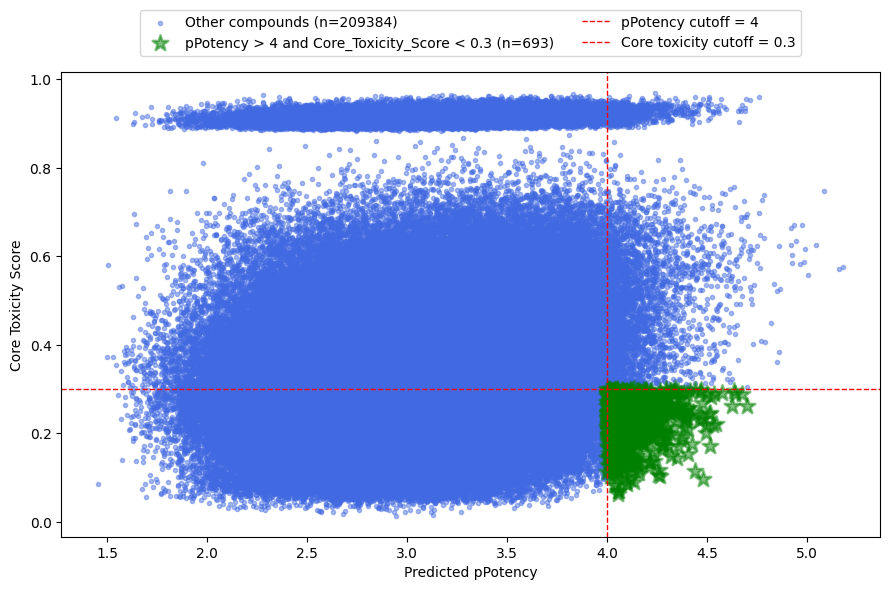

In [57]:
plotDF = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted.copy()
highlightDF = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core.copy()

# Rebuild mask from predefined cutoffs
highlightMask = (
    (plotDF["pPotency_prediction"] > pPotency_prediction_cutoff) &
    (plotDF["Core_Toxicity_Score"] < Core_Toxicity_cutoff)
)

backgroundDF = plotDF[~highlightMask]

otherCount = len(backgroundDF)
highlightCount = len(highlightDF)

plt.figure(figsize=(9, 6))

# Plot all other compounds
plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Other compounds (n={otherCount})"
)

# Plot filtered core compounds
plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Core_Toxicity_Score"],
    alpha=0.5,
    marker="*",
    s=140,
    c="g",
    linewidths=1.8,
    label=f"pPotency > {pPotency_prediction_cutoff} and Core_Toxicity_Score < {Core_Toxicity_cutoff} (n={highlightCount})"
)

plt.axvline(
    x=pPotency_prediction_cutoff,
    c="r",
    linestyle="--",
    linewidth=1,
    label=f"pPotency cutoff = {pPotency_prediction_cutoff}"
)

plt.axhline(
    y=Core_Toxicity_cutoff,
    c="r",
    linestyle="--",
    linewidth=1,
    label=f"Core toxicity cutoff = {Core_Toxicity_cutoff}"
)

plt.xlabel("Predicted pPotency")
plt.ylabel("Core Toxicity Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.tight_layout()

svg_path = os.path.join(saveDir, "BacillusAnthracisVirus_wART_allDORAnetGenerated_plot_pPotency_CoreToxicity.svg")
png_path = os.path.join(saveDir, "BacillusAnthracisVirus_wART_allDORAnetGenerated_plot_pPotency_CoreToxicity.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Create filtered dataframe with `Mechanistic_Alert_Score` & `ADME_Liability_Score`

In [43]:
# Select best overall compounds
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_allEndpoints = (
    BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted[
        (BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted["pPotency_prediction"] >= pPotency_prediction_cutoff) &
        (BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted["Core_Toxicity_Score"] < Core_Toxicity_cutoff) &
        (BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted["Mechanistic_Alert_Score"] < Mechanistic_Alert_cutoff) &
        (BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted["ADME_Liability_Score"] < ADME_Liability_cutoff)
    ]
    .copy()
)


BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_allEndpoints.to_csv(resultsDir + 
                                                                           'BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_allEndpoints.csv', index=False, encoding="utf-8")
BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_allEndpoints

,SMILES,pPotency_prediction,pPotency_std,Core_Toxicity_Desirability,Core_Toxicity_Score,Mechanistic_Alert_Desirability,Mechanistic_Alert_Score,ADME_Desirability,ADME_Liability_Score,Safety_MPO_Desirability,Safety_MPO_RiskScore,Scoring_Method_Markdown


Total compounds: 210077
Best overall compounds: 0


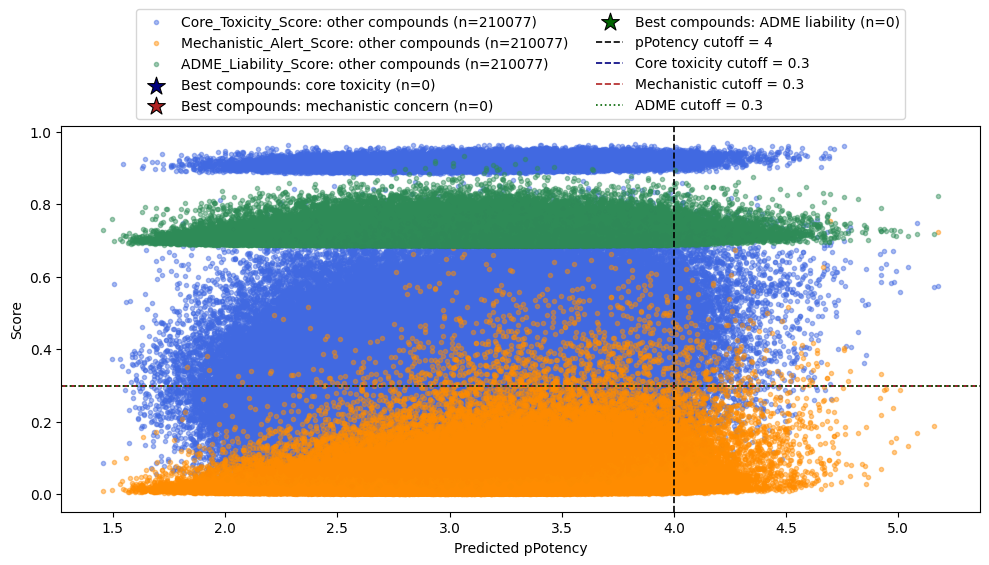

In [44]:
plotDF = BacillusAnthracisVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted.copy()

highlightMask = (
    (plotDF["pPotency_prediction"] >= pPotency_prediction_cutoff) &
    (plotDF["Core_Toxicity_Score"] < Core_Toxicity_cutoff) &
    (plotDF["Mechanistic_Alert_Score"] < Mechanistic_Alert_cutoff) &
    (plotDF["ADME_Liability_Score"] < ADME_Liability_cutoff)
)

backgroundDF = plotDF[~highlightMask]
highlightDF = plotDF[highlightMask].copy()

otherCount = len(backgroundDF)
highlightCount = len(highlightDF)
totalCount = len(plotDF)

print("Total compounds:", totalCount)
print("Best overall compounds:", highlightCount)

plt.figure(figsize=(10, 6))

# Full distributions
plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Core_Toxicity_Score: other compounds (n={otherCount})"
)

plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Mechanistic_Alert_Score"],
    alpha=0.45,
    marker=".",
    c="darkorange",
    label=f"Mechanistic_Alert_Score: other compounds (n={otherCount})"
)

plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["ADME_Liability_Score"],
    alpha=0.45,
    marker=".",
    c="seagreen",
    label=f"ADME_Liability_Score: other compounds (n={otherCount})"
)

# Highlight best compounds
plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="navy",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: core toxicity (n={highlightCount})"
)

plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Mechanistic_Alert_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="firebrick",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: mechanistic concern (n={highlightCount})"
)

plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["ADME_Liability_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="darkgreen",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: ADME liability (n={highlightCount})"
)

plt.axvline(
    x=pPotency_prediction_cutoff,
    c="black",
    linestyle="--",
    linewidth=1.2,
    label=f"pPotency cutoff = {pPotency_prediction_cutoff}"
)

plt.axhline(
    y=Core_Toxicity_cutoff,
    c="navy",
    linestyle="--",
    linewidth=1.2,
    label=f"Core toxicity cutoff = {Core_Toxicity_cutoff}"
)

plt.axhline(
    y=Mechanistic_Alert_cutoff,
    c="firebrick",
    linestyle="--",
    linewidth=1.2,
    label=f"Mechanistic cutoff = {Mechanistic_Alert_cutoff}"
)

plt.axhline(
    y=ADME_Liability_cutoff,
    c="darkgreen",
    linestyle=":",
    linewidth=1.2,
    label=f"ADME cutoff = {ADME_Liability_cutoff}"
)

plt.xlabel("Predicted pPotency")
plt.ylabel("Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.32), ncol=2)
plt.tight_layout()
plt.show()

## Check toxicty for `Basidalin` only DORANET generated AntiviralsData set

In [45]:
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_BasidalinOnlyDORAnetGenerated_Antibiotic_ARTprediction.csv')
max_val = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all['pPotency_prediction'].max()
min_val = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all

pPotency_prediction range: 2.413 → 4.628


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,C1=C(/C(=C\C=O)/OC1=O)N,True,BasidalinOnly_gen3,4.214799,1.941002,0.410435,8.019163,0.000061,9.568348e-09,0.388656
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,BasidalinOnly_gen3,3.526906,1.930244,-0.256372,7.310185,0.000297,4.895708e-08,1.804561
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,BasidalinOnly_gen3,3.252108,1.929911,-0.530518,7.034734,0.000560,9.231371e-08,3.392489
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,BasidalinOnly_gen3,2.689813,1.934148,-1.101116,6.480743,0.002043,3.305651e-07,12.621659
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,BasidalinOnly_gen3,2.674573,1.935209,-1.118437,6.467584,0.002116,3.407348e-07,13.135214
...,...,...,...,...,...,...,...,...,...,...
4125,NCC(=O)CC1(O)OC(=O)C=C1N,False,BasidalinOnly_gen3,3.487859,1.943038,-0.320496,7.296213,0.000325,5.055764e-08,2.091684
4126,NC1=CC(O)O/C1=C/C(=O)C(N)O,False,BasidalinOnly_gen3,3.983282,1.946872,0.167413,7.799151,0.000104,1.587996e-08,0.680122
4127,NCC(O)/C(O)=C1/OC(=O)C=C1N,False,BasidalinOnly_gen3,3.139712,1.949148,-0.680618,6.960042,0.000725,1.096371e-07,4.793111
4128,NCC(=O)/C(O)=C1/OC(O)C=C1N,False,BasidalinOnly_gen3,3.496918,1.951176,-0.327388,7.321224,0.000318,4.772835e-08,2.125143


### Read predicted ADMET properties for all candidate SMILES

In [46]:
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_BasidalinOnlyDORAnetGenerated_Antibiotic_ARTprediction_wToxicity.csv')
max_val = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity

pPotency_prediction range: 2.413 → 4.628


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,C1=C(/C(=C\C=O)/OC1=O)N,4.214799,1.941002,0.410435,8.019163,0.000061,9.568348e-09,0.388656,139.110,-0.53140,...,88.871656,14.579294,29.934083,43.001163,52.966266,40.131834,31.795269,31.795269,81.233036,61.302831
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,3.526906,1.930244,-0.256372,7.310185,0.000297,4.895708e-08,1.804561,507.182,-1.62900,...,5.428461,23.381155,54.633579,87.398216,4.652966,9.112059,36.719659,28.887166,89.414502,9.732454
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,2.689813,1.934148,-1.101116,6.480743,0.002043,3.305651e-07,12.621659,785.557,-2.42396,...,5.893757,12.563009,56.688639,69.910818,4.071345,53.392788,39.433889,46.219465,82.939124,2.326483
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,2.674573,1.935209,-1.118437,6.467584,0.002116,3.407348e-07,13.135214,787.573,-1.75026,...,4.769290,15.936409,61.962001,83.365646,3.140752,61.186506,42.807290,44.784800,85.071733,7.134548
4,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,3.139028,1.938263,-0.659967,6.938023,0.000726,1.153392e-07,4.570537,744.417,-2.89890,...,3.799922,19.542458,50.872431,92.904226,2.869329,13.803800,30.050407,24.505622,92.594029,16.401706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3839,NCC(=O)CC1(O)OC(=O)C=C1N,3.487859,1.943038,-0.320496,7.296213,0.000325,5.055764e-08,2.091684,186.167,-2.00770,...,37.146181,37.378829,2.869329,7.056999,12.563009,52.423420,13.532377,5.040713,94.998061,36.874758
3840,NC1=CC(O)O/C1=C/C(=O)C(N)O,3.983282,1.946872,0.167413,7.799151,0.000104,1.587996e-08,0.680122,186.167,-2.09230,...,14.967041,19.736332,7.793718,48.662272,7.871268,34.587049,17.758821,5.893757,88.018612,85.808453
3841,NCC(O)/C(O)=C1/OC(=O)C=C1N,3.139712,1.949148,-0.680618,6.960042,0.000725,1.096371e-07,4.793111,186.167,-1.52500,...,24.621946,29.701435,5.428461,37.572703,12.563009,34.082978,17.875145,16.362931,85.343156,59.092672
3842,NCC(=O)/C(O)=C1/OC(O)C=C1N,3.496918,1.951176,-0.327388,7.321224,0.000318,4.772835e-08,2.125143,186.167,-1.52500,...,19.852656,36.952307,12.175262,9.461031,18.069019,26.948430,20.317953,13.144630,89.298178,51.958123


### Retain potency predictions along with toxicity, mechanistic, and ADME-related endpoints

In [47]:
# Potency-related columns
potencyCols = [
    "SMILES",
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity.columns
]

BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity.shape)
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity.head()

Filtered dataframe shape: (3844, 41)


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,C1=C(/C(=C\C=O)/OC1=O)N,4.214799,1.941002,0.410435,8.019163,0.000061,9.568348e-09,0.388656,0.920004,0.030941,...,0.625969,0.792464,0.207908,0.073610,0.032674,0.056531,0.016988,0.001381,0.110769,0.037297
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,3.526906,1.930244,-0.256372,7.310185,0.000297,4.895708e-08,1.804561,0.033052,0.330824,...,0.024185,0.159878,0.001577,0.034541,0.056855,0.011661,0.015668,0.198030,0.076890,0.001108
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,2.689813,1.934148,-1.101116,6.480743,0.002043,3.305651e-07,12.621659,0.239975,0.900458,...,0.070120,0.380114,0.007940,0.026014,0.047826,0.052646,0.026518,0.152412,0.267949,0.046004
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,2.674573,1.935209,-1.118437,6.467584,0.002116,3.407348e-07,13.135214,0.188998,0.908109,...,0.050004,0.349236,0.005862,0.050689,0.057204,0.072706,0.040867,0.214760,0.236050,0.066886
4,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,3.139028,1.938263,-0.659967,6.938023,0.000726,1.153392e-07,4.570537,0.160844,0.619006,...,0.033647,0.122790,0.001046,0.012560,0.021261,0.009916,0.009539,0.241743,0.165820,0.002698


### Filter compounds based on the results from Drugbank's `ADMET` summary

In [48]:
# ── Build range lookup dict from summary dataframe ─────────────────────────────
# Ensure Endpoint is the index and numeric types are correct
summaryDF = drugBankDrugData_approved_ADMET_summary.copy()

if "Endpoint" in summaryDF.columns:
    summaryDF = summaryDF.set_index("Endpoint")

summaryDF = summaryDF.astype(float)

rangeDict = summaryDF[["Min", "Max"]].to_dict(orient="index")

# ── Range mask builder ─────────────────────────────────────────────────────────
def buildRangeMask(df, endpointCols, rangeDict):
    """
    Returns a boolean Series: True if ALL available endpoints in endpointCols
    fall within [Min, Max] defined in rangeDict.
    Skips endpoints missing from either the dataframe or the rangeDict.
    """
    mask = pd.Series(True, index=df.index)
    skipped = []
    applied = []

    for col in endpointCols:
        if col not in df.columns or col not in rangeDict:
            skipped.append(col)
            continue
        colMin = rangeDict[col]["Min"]
        colMax = rangeDict[col]["Max"]
        mask = mask & df[col].between(colMin, colMax, inclusive="both")
        applied.append(col)

    return mask, applied, skipped


df = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity.copy()
total = len(df)

# ── Apply masks per category ───────────────────────────────────────────────────
coreMask,        coreApplied,        coreSkipped        = buildRangeMask(df, coreToxicityCols,     rangeDict)
mechanisticMask, mechanisticApplied, mechanisticSkipped = buildRangeMask(df, mechanisticAlertCols, rangeDict)
admeMask,        admeApplied,        admeSkipped        = buildRangeMask(df, admeLiabilityCols,    rangeDict)

# Combined: must pass all three categories simultaneously
combinedMask = coreMask & mechanisticMask & admeMask

# ── Filter dataframes ──────────────────────────────────────────────────────────
df_coreFiltered        = df[coreMask].reset_index(drop=True)
df_mechanisticFiltered = df[mechanisticMask].reset_index(drop=True)
df_admeFiltered        = df[admeMask].reset_index(drop=True)
df_allFiltered         = df[combinedMask].reset_index(drop=True)

# ── Report 
print("         DrugBank Approved Range Filtering Summary")
print(f"Total input molecules: {total}")

print(f"\n──> Core Toxicity Endpoints ")
print(f"  Endpoints applied : {coreApplied}")
print(f"  Endpoints skipped : {coreSkipped}")
print(f"  Passing molecules : {len(df_coreFiltered)} / {total}  ({len(df_coreFiltered)/total*100:.2f}%)")

print(f"\n──> Mechanistic Alert Endpoints ")
print(f"  Endpoints applied : {mechanisticApplied}")
print(f"  Endpoints skipped : {mechanisticSkipped}")
print(f"  Passing molecules : {len(df_mechanisticFiltered)} / {total}  ({len(df_mechanisticFiltered)/total*100:.2f}%)")

print(f"\n──> ADME / Metabolism Liability Endpoints ")
print(f"  Endpoints applied : {admeApplied}")
print(f"  Endpoints skipped : {admeSkipped}")
print(f"  Passing molecules : {len(df_admeFiltered)} / {total}  ({len(df_admeFiltered)/total*100:.2f}%)")

print(f"\n──> Combined (ALL categories must pass) ")
print(f"  Passing molecules : {len(df_allFiltered)} / {total}  ({len(df_allFiltered)/total*100:.2f}%)")
print("=" * 65)

# ── Inspect results ────────────────────────────────────────────────────────────
print("\nCombined filtered dataframe shape:", df_allFiltered.shape)
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity = df_allFiltered.copy()
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity

         DrugBank Approved Range Filtering Summary
Total input molecules: 3844

──> Core Toxicity Endpoints 
  Endpoints applied : ['AMES', 'hERG', 'DILI', 'ClinTox', 'Carcinogens_Lagunin', 'Skin_Reaction', 'LD50_Zhu']
  Endpoints skipped : []
  Passing molecules : 3844 / 3844  (100.00%)

──> Mechanistic Alert Endpoints 
  Endpoints applied : ['SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'NR-AR-LBD', 'NR-AR', 'NR-AhR', 'NR-Aromatase', 'NR-ER-LBD', 'NR-ER', 'NR-PPAR-gamma']
  Endpoints skipped : []
  Passing molecules : 3844 / 3844  (100.00%)

──> ADME / Metabolism Liability Endpoints 
  Endpoints applied : ['BBB_Martins', 'Pgp_Broccatelli', 'Caco2_Wang', 'HIA_Hou', 'PAMPA_NCATS', 'Bioavailability_Ma', 'CYP1A2_Veith', 'CYP2C19_Veith', 'CYP2C9_Substrate_CarbonMangels', 'CYP2C9_Veith', 'CYP2D6_Substrate_CarbonMangels', 'CYP2D6_Veith', 'CYP3A4_Substrate_CarbonMangels', 'CYP3A4_Veith']
  Endpoints skipped : []
  Passing molecules : 3844 / 3844  (100.00%)

──> Combined (ALL categories

,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,C1=C(/C(=C\C=O)/OC1=O)N,4.214799,1.941002,0.410435,8.019163,0.000061,9.568348e-09,0.388656,0.920004,0.030941,...,0.625969,0.792464,0.207908,0.073610,0.032674,0.056531,0.016988,0.001381,0.110769,0.037297
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,3.526906,1.930244,-0.256372,7.310185,0.000297,4.895708e-08,1.804561,0.033052,0.330824,...,0.024185,0.159878,0.001577,0.034541,0.056855,0.011661,0.015668,0.198030,0.076890,0.001108
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,2.689813,1.934148,-1.101116,6.480743,0.002043,3.305651e-07,12.621659,0.239975,0.900458,...,0.070120,0.380114,0.007940,0.026014,0.047826,0.052646,0.026518,0.152412,0.267949,0.046004
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,2.674573,1.935209,-1.118437,6.467584,0.002116,3.407348e-07,13.135214,0.188998,0.908109,...,0.050004,0.349236,0.005862,0.050689,0.057204,0.072706,0.040867,0.214760,0.236050,0.066886
4,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,3.139028,1.938263,-0.659967,6.938023,0.000726,1.153392e-07,4.570537,0.160844,0.619006,...,0.033647,0.122790,0.001046,0.012560,0.021261,0.009916,0.009539,0.241743,0.165820,0.002698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3839,NCC(=O)CC1(O)OC(=O)C=C1N,3.487859,1.943038,-0.320496,7.296213,0.000325,5.055764e-08,2.091684,0.610947,0.008204,...,0.197496,0.909300,0.009542,0.015091,0.061113,0.007667,0.021701,0.001856,0.084969,0.003952
3840,NC1=CC(O)O/C1=C/C(=O)C(N)O,3.983282,1.946872,0.167413,7.799151,0.000104,1.587996e-08,0.680122,0.722526,0.023280,...,0.272367,0.770575,0.069917,0.045379,0.054939,0.025870,0.033994,0.015409,0.057963,0.025453
3841,NCC(O)/C(O)=C1/OC(=O)C=C1N,3.139712,1.949148,-0.680618,6.960042,0.000725,1.096371e-07,4.793111,0.430927,0.022838,...,0.237720,0.784582,0.177349,0.024815,0.061054,0.019208,0.026543,0.002589,0.041076,0.011553
3842,NCC(=O)/C(O)=C1/OC(O)C=C1N,3.496918,1.951176,-0.327388,7.321224,0.000318,4.772835e-08,2.125143,0.541087,0.012251,...,0.242008,0.849451,0.077419,0.021771,0.046486,0.014441,0.024786,0.010725,0.076363,0.011536


### Multiparameter optimization (MPO) framework based ADMET scoring

We replaced simple arithmetic averaging with a weighted desirability-based multiparameter optimization (MPO) framework. Each ADMET endpoint was converted to a 0–1 desirability value, where `1 --> favorable` and `0 --> unfavorable` profile. Category-level scores were then combined using weighted geometric means, following the same general pattern used in QED and ADMET-score approaches.

**References**

1. ADMET-score – a comprehensive scoring function for evaluation of chemical drug-likeness (https://pubs.rsc.org/en/content/articlelanding/2019/md/c8md00472b)
2. Quantifying the chemical beauty of drugs (https://www.nature.com/articles/nchem.1243)

In [49]:
df = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity.copy()


# Endpoint groups
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu",
]

mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma",
]

# Define these lists according to how you want to treat directionality
# lower-is-better => toxicity/liability style probabilities
admeLowerIsBetter = [
    "Pgp_Broccatelli",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith",
]

# higher-is-better => absorption / permeability / bioavailability style endpoints
admeHigherIsBetter = [
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
]

# Optional / context-dependent endpoint
# For non-CNS antivirals, you may wish to penalize BBB penetration.
# For CNS programs, you may want the opposite or exclude it from the score.
includeBBB = False
if includeBBB and "BBB_Martins" in df.columns:
    admeLowerIsBetter = admeLowerIsBetter + ["BBB_Martins"]


# Utilities
epsilon = 1e-6

def clip01(series):
    return series.clip(lower=epsilon, upper=1 - epsilon)

def desirabilityFromRiskProbability(series):
    """
    For toxicity/liability probabilities:
    lower risk is better -> desirability = 1 - p
    """
    return clip01(1 - series)

def desirabilityFromBenefitProbability(series):
    """
    For favorable probabilities/scores already in [0,1]:
    higher is better -> desirability = p
    """
    return clip01(series)

def desirabilityFromLD50(series, lowerQuantile=0.10, upperQuantile=0.90):
    """
    LD50_Zhu is treated as a regression-style acute toxicity endpoint.
    Higher LD50_Zhu implies greater acute toxicity risk.
    Map lower values -> high desirability, higher values -> low desirability.

    Uses a robust percentile-based linear desirability transform so the score
    is less sensitive to extreme outliers than plain min-max scaling.
    """
    qLow = series.quantile(lowerQuantile)
    qHigh = series.quantile(upperQuantile)

    if pd.isna(qLow) or pd.isna(qHigh) or qHigh == qLow:
        return pd.Series(0.5, index=series.index)

    # lower LD50_Zhu = better, higher = worse
    desirability = 1 - ((series - qLow) / (qHigh - qLow))
    return clip01(desirability)

def weightedGeometricMean(dfValues, weightsDict):
    """
    Compute weighted geometric mean across available columns only.
    """
    availableCols = [col for col in weightsDict if col in dfValues.columns]
    if len(availableCols) == 0:
        return pd.Series(np.nan, index=dfValues.index)

    weights = np.array([weightsDict[col] for col in availableCols], dtype=float)
    weights = weights / weights.sum()

    values = dfValues[availableCols].copy()
    values = values.clip(lower=epsilon, upper=1 - epsilon)

    logWeighted = np.log(values).mul(weights, axis=1).sum(axis=1)
    return np.exp(logWeighted)

# -----------------------------------------------------------------------------
# 1. Core toxicity desirability
# -----------------------------------------------------------------------------
coreWeights = {
    "AMES": 1.0,
    "hERG": 1.5,
    "DILI": 1.5,
    "ClinTox": 1.5,
    "Carcinogens_Lagunin": 1.0,
    "Skin_Reaction": 0.5,
    "LD50_Zhu": 1.25,
}

coreDesirabilityDF = pd.DataFrame(index=df.index)

for colName in coreToxicityCols:
    if colName not in df.columns:
        continue

    if colName == "LD50_Zhu":
        coreDesirabilityDF[colName] = desirabilityFromLD50(df[colName])
    else:
        coreDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

df["Core_Toxicity_Desirability"] = weightedGeometricMean(coreDesirabilityDF, coreWeights)

# Optional inverse form if you want "higher = worse"
df["Core_Toxicity_Score"] = 1 - df["Core_Toxicity_Desirability"]

# -----------------------------------------------------------------------------
# 2. Mechanistic alert desirability
# -----------------------------------------------------------------------------
mechWeights = {
    "SR-ARE": 1.0,
    "SR-ATAD5": 1.0,
    "SR-HSE": 0.75,
    "SR-MMP": 1.25,
    "SR-p53": 1.0,
    "NR-AR-LBD": 0.75,
    "NR-AR": 0.75,
    "NR-AhR": 0.75,
    "NR-Aromatase": 0.75,
    "NR-ER-LBD": 0.75,
    "NR-ER": 0.75,
    "NR-PPAR-gamma": 0.5,
}

mechDesirabilityDF = pd.DataFrame(index=df.index)
for colName in mechanisticAlertCols:
    if colName in df.columns:
        mechDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

df["Mechanistic_Alert_Desirability"] = weightedGeometricMean(mechDesirabilityDF, mechWeights)
df["Mechanistic_Alert_Score"] = 1 - df["Mechanistic_Alert_Desirability"]

# -----------------------------------------------------------------------------
# 3. ADME liability desirability
# -----------------------------------------------------------------------------
admeWeights = {
    "BBB_Martins": 0.5,   # context dependent
    "Pgp_Broccatelli": 1.0,
    "Caco2_Wang": 1.0,
    "HIA_Hou": 1.0,
    "PAMPA_NCATS": 0.75,
    "Bioavailability_Ma": 1.25,
    "CYP1A2_Veith": 1.0,
    "CYP2C19_Veith": 1.0,
    "CYP2C9_Substrate_CarbonMangels": 0.75,
    "CYP2C9_Veith": 1.0,
    "CYP2D6_Substrate_CarbonMangels": 0.75,
    "CYP2D6_Veith": 1.0,
    "CYP3A4_Substrate_CarbonMangels": 0.75,
    "CYP3A4_Veith": 1.0,
}

admeDesirabilityDF = pd.DataFrame(index=df.index)

for colName in admeLowerIsBetter:
    if colName in df.columns:
        admeDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

for colName in admeHigherIsBetter:
    if colName in df.columns:
        admeDesirabilityDF[colName] = desirabilityFromBenefitProbability(df[colName])

df["ADME_Desirability"] = weightedGeometricMean(admeDesirabilityDF, admeWeights)
df["ADME_Liability_Score"] = 1 - df["ADME_Desirability"]

# -----------------------------------------------------------------------------
# 4. Final MPO-style safety score
# -----------------------------------------------------------------------------
# Higher desirability = better
# We give core toxicity the highest influence, then ADME, then mechanistic alerts.
componentDesirabilityDF = pd.DataFrame({
    "Core_Toxicity_Desirability": df["Core_Toxicity_Desirability"],
    "Mechanistic_Alert_Desirability": df["Mechanistic_Alert_Desirability"],
    "ADME_Desirability": df["ADME_Desirability"],
})

componentWeights = {
    "Core_Toxicity_Desirability": 0.50,
    "Mechanistic_Alert_Desirability": 0.20,
    "ADME_Desirability": 0.30,
}

df["Safety_MPO_Desirability"] = weightedGeometricMean(
    componentDesirabilityDF,
    componentWeights
)

# Optional inverse form if you want higher = worse
df["Safety_MPO_RiskScore"] = 1 - df["Safety_MPO_Desirability"]

# -----------------------------------------------------------------------------
# 5. Markdown-style explanation column
# -----------------------------------------------------------------------------
markdownNote = (
    "Composite scores were computed using a weighted desirability-based MPO framework. "
    "Each endpoint was transformed to a 0–1 desirability value, then combined with a "
    "weighted geometric mean. Core toxicity used AMES, hERG, DILI, ClinTox, "
    "Carcinogens_Lagunin, Skin_Reaction, and LD50_Zhu; mechanistic score used SR/NR "
    "alerts; ADME score used direction-adjusted absorption, transporter, and CYP endpoints. "
    "This follows the general scoring pattern used in QED and ADMET-score literature."
)

df["Scoring_Method_Markdown"] = markdownNote

# -----------------------------------------------------------------------------
# 6. Final output
# -----------------------------------------------------------------------------
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted = df[
    [
        "SMILES",
        "pPotency_prediction",
        "pPotency_std",
        "Core_Toxicity_Desirability",
        "Core_Toxicity_Score",
        "Mechanistic_Alert_Desirability",
        "Mechanistic_Alert_Score",
        "ADME_Desirability",
        "ADME_Liability_Score",
        "Safety_MPO_Desirability",
        "Safety_MPO_RiskScore",
        "Scoring_Method_Markdown",
    ]
].copy()

BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted

,SMILES,pPotency_prediction,pPotency_std,Core_Toxicity_Desirability,Core_Toxicity_Score,Mechanistic_Alert_Desirability,Mechanistic_Alert_Score,ADME_Desirability,ADME_Liability_Score,Safety_MPO_Desirability,Safety_MPO_RiskScore,Scoring_Method_Markdown
0,C1=C(/C(=C\C=O)/OC1=O)N,4.214799,1.941002,0.272694,0.727306,0.673436,0.326564,0.292990,0.707010,0.333851,0.666149,Composite scores were computed using a weighte...
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,3.526906,1.930244,0.665276,0.334724,0.959302,0.040698,0.152200,0.847800,0.459850,0.540150,Composite scores were computed using a weighte...
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,2.689813,1.934148,0.259184,0.740816,0.886391,0.113609,0.204777,0.795223,0.308825,0.691175,Composite scores were computed using a weighte...
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,2.674573,1.935209,0.179750,0.820250,0.914057,0.085943,0.194188,0.805812,0.254681,0.745319,Composite scores were computed using a weighte...
4,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,3.139028,1.938263,0.622275,0.377725,0.937107,0.062893,0.143793,0.856207,0.435182,0.564818,Composite scores were computed using a weighte...
...,...,...,...,...,...,...,...,...,...,...,...,...
3839,NCC(=O)CC1(O)OC(=O)C=C1N,3.487859,1.943038,0.484531,0.515469,0.951459,0.048541,0.286021,0.713979,0.473433,0.526567,Composite scores were computed using a weighte...
3840,NC1=CC(O)O/C1=C/C(=O)C(N)O,3.983282,1.946872,0.603203,0.396797,0.915012,0.084988,0.283296,0.716704,0.522624,0.477376,Composite scores were computed using a weighte...
3841,NCC(O)/C(O)=C1/OC(=O)C=C1N,3.139712,1.949148,0.612774,0.387226,0.938236,0.061764,0.279659,0.720341,0.527353,0.472647,Composite scores were computed using a weighte...
3842,NCC(=O)/C(O)=C1/OC(O)C=C1N,3.496918,1.951176,0.672650,0.327350,0.944330,0.055670,0.285556,0.714444,0.556707,0.443293,Composite scores were computed using a weighte...


### Define filter for compound ranking based on `ADMET` scores

In [50]:
pPotency_prediction_cutoff = 4
Core_Toxicity_cutoff = 0.3
Mechanistic_Alert_cutoff = 0.3
ADME_Liability_cutoff = 0.3

In [51]:
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_core = (
    BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted[
        (BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted["pPotency_prediction"] > pPotency_prediction_cutoff) &
        (BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted["Core_Toxicity_Score"] < Core_Toxicity_cutoff)
    ]
    .reset_index(drop=True)
)


BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_core.to_csv(resultsDir + 
                                                                           'BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_nonToxic_core.csv', index=False, encoding="utf-8")
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_core

,SMILES,pPotency_prediction,pPotency_std,Core_Toxicity_Desirability,Core_Toxicity_Score,Mechanistic_Alert_Desirability,Mechanistic_Alert_Score,ADME_Desirability,ADME_Liability_Score,Safety_MPO_Desirability,Safety_MPO_RiskScore,Scoring_Method_Markdown
0,NC(C=CC(=O)O)=CC(=O)O,4.262504,1.949428,0.732900,0.267100,0.921996,0.078004,0.235792,0.764208,0.546043,0.453957,Composite scores were computed using a weighte...
1,COC1C=C(N)C(C(O)C=O)O1,4.003327,1.948211,0.748666,0.251334,0.990580,0.009420,0.287750,0.712250,0.594329,0.405671,Composite scores were computed using a weighte...
2,NC(=O)C=C(O)C=CC(=O)O,4.124498,1.947166,0.792691,0.207309,0.954219,0.045781,0.248941,0.751059,0.581180,0.418820,Composite scores were computed using a weighte...
3,NC(C=C(O)O)C(=O)CC=O,4.127402,1.942055,0.721876,0.278124,0.976030,0.023970,0.257520,0.742480,0.562817,0.437183,Composite scores were computed using a weighte...
4,COC(=O)C=C(N)C(N)CC=O,4.054585,1.937673,0.754889,0.245111,0.987436,0.012564,0.291515,0.708485,0.598745,0.401255,Composite scores were computed using a weighte...
5,NC(=CC(N)(O)O)C(=O)CC=O,4.148389,1.935329,0.700292,0.299708,0.968696,0.031304,0.250933,0.749067,0.549217,0.450783,Composite scores were computed using a weighte...
6,NC1=CC(O)OC(C=O)C1N,4.086372,1.946410,0.713556,0.286444,0.964449,0.035551,0.277556,0.722444,0.570920,0.429080,Composite scores were computed using a weighte...
7,NC(=CC(=O)O)C(N)(CC=O)CC=O,4.024298,1.955343,0.719888,0.280112,0.994426,0.005574,0.253789,0.746211,0.561680,0.438320,Composite scores were computed using a weighte...
8,NC(=CC(=O)O)C(N)C(C=O)C=O,4.031710,1.941154,0.731664,0.268336,0.972775,0.027225,0.249166,0.750834,0.560667,0.439333,Composite scores were computed using a weighte...


### Plot full distribution + highlighted filtered dataframe

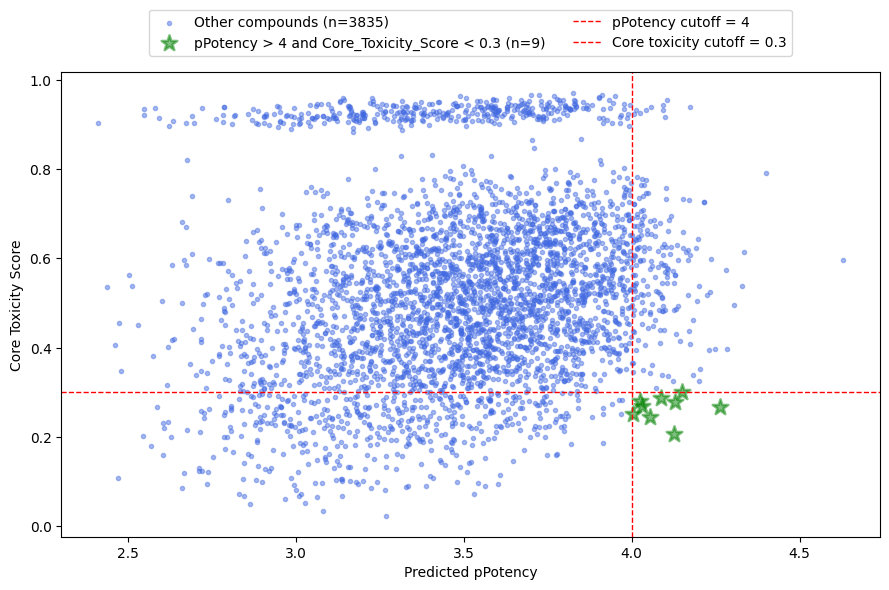

In [52]:
plotDF = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted.copy()
highlightDF = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_core.copy()

# Rebuild mask from predefined cutoffs
highlightMask = (
    (plotDF["pPotency_prediction"] > pPotency_prediction_cutoff) &
    (plotDF["Core_Toxicity_Score"] < Core_Toxicity_cutoff)
)

backgroundDF = plotDF[~highlightMask]

otherCount = len(backgroundDF)
highlightCount = len(highlightDF)

plt.figure(figsize=(9, 6))

# Plot all other compounds
plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Other compounds (n={otherCount})"
)

# Plot filtered core compounds
plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Core_Toxicity_Score"],
    alpha=0.5,
    marker="*",
    s=140,
    c="g",
    linewidths=1.8,
    label=f"pPotency > {pPotency_prediction_cutoff} and Core_Toxicity_Score < {Core_Toxicity_cutoff} (n={highlightCount})"
)

plt.axvline(
    x=pPotency_prediction_cutoff,
    c="r",
    linestyle="--",
    linewidth=1,
    label=f"pPotency cutoff = {pPotency_prediction_cutoff}"
)

plt.axhline(
    y=Core_Toxicity_cutoff,
    c="r",
    linestyle="--",
    linewidth=1,
    label=f"Core toxicity cutoff = {Core_Toxicity_cutoff}"
)

plt.xlabel("Predicted pPotency")
plt.ylabel("Core Toxicity Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.tight_layout()
plt.show()

### Create filtered dataframe with `Mechanistic_Alert_Score` & `ADME_Liability_Score`

In [53]:
# Select best overall compounds
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_allEndpoints = (
    BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted[
        (BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted["pPotency_prediction"] >= pPotency_prediction_cutoff) &
        (BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted["Core_Toxicity_Score"] < Core_Toxicity_cutoff) &
        (BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted["Mechanistic_Alert_Score"] < Mechanistic_Alert_cutoff) &
        (BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted["ADME_Liability_Score"] < ADME_Liability_cutoff)
    ]
    .copy()
)


BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_allEndpoints.to_csv(resultsDir + 
                                                                           'BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_allEndpoints.csv', index=False, encoding="utf-8")
BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_allEndpoints

,SMILES,pPotency_prediction,pPotency_std,Core_Toxicity_Desirability,Core_Toxicity_Score,Mechanistic_Alert_Desirability,Mechanistic_Alert_Score,ADME_Desirability,ADME_Liability_Score,Safety_MPO_Desirability,Safety_MPO_RiskScore,Scoring_Method_Markdown


Total compounds: 3844
Best overall compounds: 0


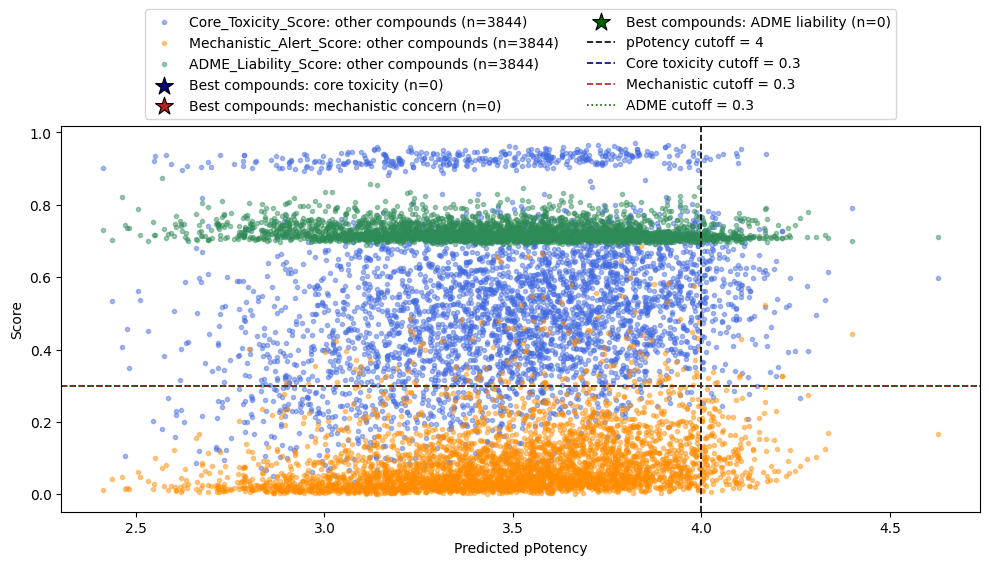

In [54]:
plotDF = BacillusAnthracisVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted.copy()

highlightMask = (
    (plotDF["pPotency_prediction"] >= pPotency_prediction_cutoff) &
    (plotDF["Core_Toxicity_Score"] < Core_Toxicity_cutoff) &
    (plotDF["Mechanistic_Alert_Score"] < Mechanistic_Alert_cutoff) &
    (plotDF["ADME_Liability_Score"] < ADME_Liability_cutoff)
)

backgroundDF = plotDF[~highlightMask]
highlightDF = plotDF[highlightMask].copy()

otherCount = len(backgroundDF)
highlightCount = len(highlightDF)
totalCount = len(plotDF)

print("Total compounds:", totalCount)
print("Best overall compounds:", highlightCount)

plt.figure(figsize=(10, 6))

# Full distributions
plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Core_Toxicity_Score: other compounds (n={otherCount})"
)

plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Mechanistic_Alert_Score"],
    alpha=0.45,
    marker=".",
    c="darkorange",
    label=f"Mechanistic_Alert_Score: other compounds (n={otherCount})"
)

plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["ADME_Liability_Score"],
    alpha=0.45,
    marker=".",
    c="seagreen",
    label=f"ADME_Liability_Score: other compounds (n={otherCount})"
)

# Highlight best compounds
plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="navy",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: core toxicity (n={highlightCount})"
)

plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Mechanistic_Alert_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="firebrick",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: mechanistic concern (n={highlightCount})"
)

plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["ADME_Liability_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="darkgreen",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: ADME liability (n={highlightCount})"
)

plt.axvline(
    x=pPotency_prediction_cutoff,
    c="black",
    linestyle="--",
    linewidth=1.2,
    label=f"pPotency cutoff = {pPotency_prediction_cutoff}"
)

plt.axhline(
    y=Core_Toxicity_cutoff,
    c="navy",
    linestyle="--",
    linewidth=1.2,
    label=f"Core toxicity cutoff = {Core_Toxicity_cutoff}"
)

plt.axhline(
    y=Mechanistic_Alert_cutoff,
    c="firebrick",
    linestyle="--",
    linewidth=1.2,
    label=f"Mechanistic cutoff = {Mechanistic_Alert_cutoff}"
)

plt.axhline(
    y=ADME_Liability_cutoff,
    c="darkgreen",
    linestyle=":",
    linewidth=1.2,
    label=f"ADME cutoff = {ADME_Liability_cutoff}"
)

plt.xlabel("Predicted pPotency")
plt.ylabel("Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.32), ncol=2)
plt.tight_layout()
plt.show()